# 28 — Publication Figures

Regenerates, in one place and in a single consistent style, every figure used in
`docs/Manuscript/main.tex` **except Figure 1** (`system.jpeg`, prepared manually).

Style follows the house style established in the companion heat-exchanger paper
(`sbi_mcmc_heat_exchanger/src/hx_models/style.py`): serif fonts, Computer Modern
math, Okabe-Ito colourblind-safe palette, `seaborn-v0_8-whitegrid` axes — see
`cstr_sbi.style.apply_paper_style()`.

Figures produced here (manuscript order):

1. `nb21_cl_vs_ol_masking.png` — System~II control masking (Fig.~2). **Redesigned**
   this session: the previous 2x2 grid (rows = scenario, columns = $T_r$/$T_j$) is
   replaced by two vertically stacked panels (one per scenario), each merging
   $T_r$ and $T_j$ into a single combined temperature axis.
2. `03_physics_features_scatter.png` — System~I physics-informed feature scatter.
3. `04_posterior_recovery.png` — System~I posterior recovery, Sc\,1 vs Sc\,2.
4. `10_degradation_tracking.png` — System~I 30-day amortised SBI tracking.
5. `nb31_confusion_matrix.png` — System~II unit-level fault confusion matrix.
6. `nb23_fim_heatmap_single.png` — System~II Fisher information, S-B vs S-A.

Each section is self-contained (its own imports) and prefers loading already-cached
artifacts (trained posteriors, cached results) over recomputing expensive pipelines —
mirroring the load-vs-recompute pattern already used by the notebook that originally
produced each figure. **Run all cells top to bottom.**


In [80]:
import sys, pathlib
sys.path.insert(0, '../src')
sys.path.insert(0, '../scripts')

import numpy as np
import matplotlib.pyplot as plt

from cstr_sbi.style import (
    apply_paper_style, save_fig, OI,
    SBI_COLOR, EKF_COLOR, TRUE_COLOR, CL_COLOR, OL_COLOR,
    TR_COLOR, TJ_COLOR, PARAM_LABELS_SYS1, PARAM_LABELS_SYS2,
)

apply_paper_style()

ROOT    = pathlib.Path.cwd().parent
DATA    = ROOT / "data"
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

print("Publication-figure notebook — style applied, paths resolved.")
print(f"FIGURES = {FIGURES}")


Publication-figure notebook — style applied, paths resolved.
FIGURES = /Users/simo/inso-po-RD/cstr-model-optimisation/research_project/figures


## 1. Control masking, System II (`nb21_cl_vs_ol_masking.png`, Fig.~2)

Closed-loop (CL) vs. open-loop (OL) response of $T_r$ and $T_j$ to jacket fouling
($\beta_r$), at two severities (W5 mild, W6 severe). Reproduces the deterministic
20 h windows from `notebooks/21_wu2003_control_structures.ipynb` \S6.

**Redesign for this session:** the original figure was a 2x2 grid (rows =
scenario, columns = $T_r$ / $T_j$ as separate panels). Per explicit request, the
two variable panels are now merged into one combined-temperature panel per
scenario ($T_r$ and $T_j$ share a y-axis — both are in K — distinguished by
colour; CL/OL distinguished by line style), giving two panels stacked
vertically (one per scenario) instead of four.


In [86]:
from cstr_sbi.recycle.physics import T_SP, T_J_NOM
from cstr_sbi.recycle.scenarios import get_scenario, SCENARIO_CONFIGS
from cstr_sbi.recycle.simulator import nominal_warm_start, deterministic_window

# 20 h window saved every 10 min, including both endpoints.
T_FINAL_H = 20.0
SAVE_INTERVAL_MIN = 2.0
N_SAVE_MASKING = int(T_FINAL_H * 60 / SAVE_INTERVAL_MIN) + 1

print("Computing S-B warm start...")
y0_sb = nominal_warm_start("S-B")

sc_w5_cl = get_scenario("W5_jacket_mild")
sc_w6_cl = get_scenario("W6_jacket_severe")
sc_w5_ol = SCENARIO_CONFIGS["W5_jacket_mild_ol"]
sc_w6_ol = SCENARIO_CONFIGS["W6_jacket_severe_ol"]

print(
    f"Running W5/W6, closed-loop and open-loop, under S-B "
    f"({T_FINAL_H:.0f} h window, {SAVE_INTERVAL_MIN:.0f} min save interval)..."
)
t5, r_w5_cl = deterministic_window(sc_w5_cl, structure="S-B", y0=y0_sb, t_final_h=T_FINAL_H, n_save=N_SAVE_MASKING)
_,  r_w5_ol = deterministic_window(sc_w5_ol, structure="S-B", y0=y0_sb, t_final_h=T_FINAL_H, n_save=N_SAVE_MASKING)
t6, r_w6_cl = deterministic_window(sc_w6_cl, structure="S-B", y0=y0_sb, t_final_h=T_FINAL_H, n_save=N_SAVE_MASKING)
_,  r_w6_ol = deterministic_window(sc_w6_ol, structure="S-B", y0=y0_sb, t_final_h=T_FINAL_H, n_save=N_SAVE_MASKING)

t5, t6 = np.asarray(t5), np.asarray(t6)
r_w5_cl, r_w5_ol = np.asarray(r_w5_cl), np.asarray(r_w5_ol)
r_w6_cl, r_w6_ol = np.asarray(r_w6_cl), np.asarray(r_w6_ol)
print(f"Done. Saved points per trajectory: {N_SAVE_MASKING}; dt={np.diff(t5).mean() * 60:.1f} min")

Computing S-B warm start...
Running W5/W6, closed-loop and open-loop, under S-B (20 h window, 2 min save interval)...
Done. Saved points per trajectory: 601; dt=2.0 min


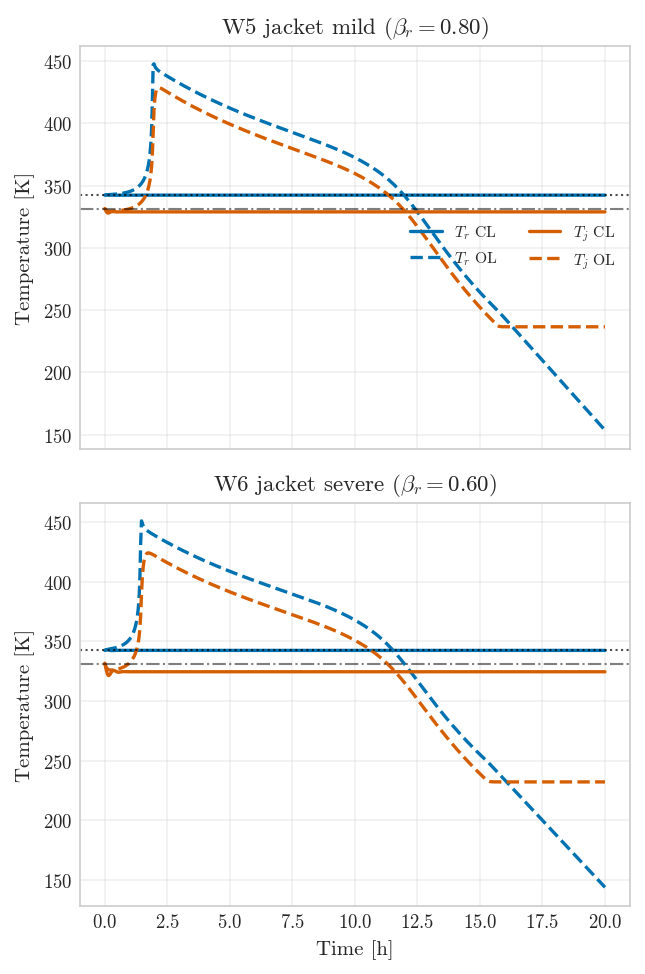

W5 CL T_r max dev from setpoint: 0.1935 K
W5 OL T_r max dev from setpoint: 188.7827 K
W6 CL T_r max dev from setpoint: 0.4761 K
W6 OL T_r max dev from setpoint: 198.4836 K
Saved nb21_cl_vs_ol_masking.png (merged T_r/T_j panels, 2 stacked vertically)


In [87]:
tsp = float(T_SP)
tj_nom = float(T_J_NOM)

fig, axes = plt.subplots(2, 1, figsize=(4.4, 6.6), sharex=True)

panels = [
    (axes[0], t5, r_w5_cl, r_w5_ol, "W5 jacket mild", r"$\beta_r=0.80$"),
    (axes[1], t6, r_w6_cl, r_w6_ol, "W6 jacket severe", r"$\beta_r=0.60$"),
]

for ax, t, r_cl, r_ol, sc_label, beta_lbl in panels:
    ax.plot(t, r_cl[:, 0], color=TR_COLOR, lw=1.6, ls='-',  label=r'$T_r$ CL')
    ax.plot(t, r_ol[:, 0], color=TR_COLOR, lw=1.6, ls='--', label=r'$T_r$ OL')
    ax.plot(t, r_cl[:, 1], color=TJ_COLOR, lw=1.6, ls='-',  label=r'$T_j$ CL')
    ax.plot(t, r_ol[:, 1], color=TJ_COLOR, lw=1.6, ls='--', label=r'$T_j$ OL')
    ax.axhline(tsp, color=OI[0], ls=':', lw=1.0, alpha=0.7)
    ax.axhline(tj_nom, color=OI[0], ls='-.', lw=1.0, alpha=0.5)
    ax.set_ylabel("Temperature [K]")
    ax.set_title(f"{sc_label} ({beta_lbl})")
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=7.5, ncol=2, loc='center right')
axes[1].set_xlabel("Time [h]")

fig.tight_layout()
save_fig(fig, FIGURES / "nb21_cl_vs_ol_masking")
plt.show()

print(f"W5 CL T_r max dev from setpoint: {np.max(np.abs(r_w5_cl[:,0]-tsp)):.4f} K")
print(f"W5 OL T_r max dev from setpoint: {np.max(np.abs(r_w5_ol[:,0]-tsp)):.4f} K")
print(f"W6 CL T_r max dev from setpoint: {np.max(np.abs(r_w6_cl[:,0]-tsp)):.4f} K")
print(f"W6 OL T_r max dev from setpoint: {np.max(np.abs(r_w6_ol[:,0]-tsp)):.4f} K")
print("Saved nb21_cl_vs_ol_masking.png (merged T_r/T_j panels, 2 stacked vertically)")


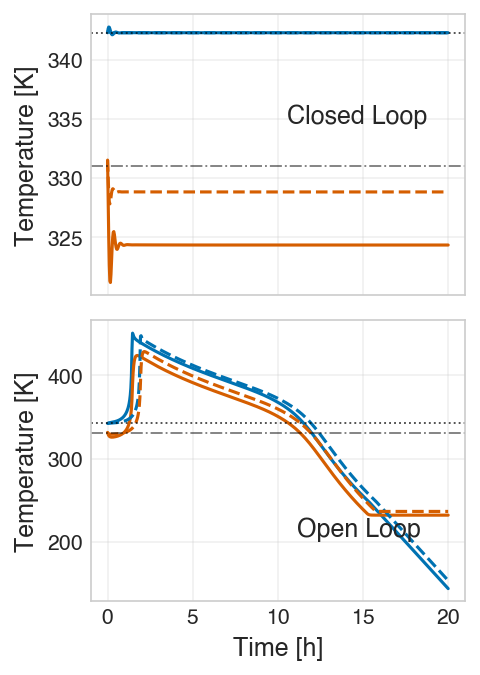

In [88]:
# W5/W6 closed-loop response in the top panel; W5/W6 open-loop response in the bottom panel.
# The x-axis is shared, but each panel keeps its own y-axis scaling and square axes box.

_, t_w5, r_w5_cl_plot, r_w5_ol_plot, _, _ = panels[0]
_, t_w6, r_w6_cl_plot, r_w6_ol_plot, sc_label, beta_lbl = panels[1]
font_kwargs = {"fontname": "Helvetica"}

text_locations = {
    "Closed Loop": (0.525, 0.68),
    "Open Loop": (0.55, 0.30),
}
legend_locations = {
    "Closed Loop": "best",
    "Open Loop": "best",
}

fig, axes = plt.subplots(2, 1, figsize=(3, 4.5), sharex=True)

axes[0].plot(t_w6, r_w6_cl_plot[:, 0], color=TR_COLOR, lw=1.5, ls='-', label=r'W6 $T_r$')
axes[0].plot(t_w6, r_w6_cl_plot[:, 1], color=TJ_COLOR, lw=1.5, ls='-', label=r'W6 $T_j$')
axes[0].plot(t_w5, r_w5_cl_plot[:, 0], color=TR_COLOR, lw=1.5, ls='--', label=r'W5 $T_r$')
axes[0].plot(t_w5, r_w5_cl_plot[:, 1], color=TJ_COLOR, lw=1.5, ls='--', label=r'W5 $T_j$')

axes[1].plot(t_w6, r_w6_ol_plot[:, 0], color=TR_COLOR, lw=1.5, ls='-', label=r'W6 $T_r$')
axes[1].plot(t_w6, r_w6_ol_plot[:, 1], color=TJ_COLOR, lw=1.5, ls='-', label=r'W6 $T_j$')
axes[1].plot(t_w5, r_w5_ol_plot[:, 0], color=TR_COLOR, lw=1.5, ls='--', label=r'W5 $T_r$')
axes[1].plot(t_w5, r_w5_ol_plot[:, 1], color=TJ_COLOR, lw=1.5, ls='--', label=r'W5 $T_j$')

for ax, panel_label in zip(axes, ["Closed Loop", "Open Loop"]):
    ax.axhline(tsp, color=OI[0], ls=':', lw=0.9, alpha=0.7)
    ax.axhline(tj_nom, color=OI[0], ls='-.', lw=0.9, alpha=0.5)

    ax.set_box_aspect(0.75)
    ax.set_ylabel("Temperature [K]", fontsize=12, **font_kwargs)
    ax.text(*text_locations[panel_label], panel_label, transform=ax.transAxes,
            fontsize=12, weight='bold', ha='left', va='top', **font_kwargs)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=10)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontname("Helvetica")
    # (legend intentionally omitted here -- W5/W6 x T_r/T_j already distinguished by
    # colour/linestyle and annotated via the panel_label text above)

axes[1].set_xlabel("Time [h]", fontsize=12, **font_kwargs)
fig.tight_layout(pad=0.4, h_pad=0.6)

save_fig(fig, FIGURES / "nb21_cl_vs_ol_masking_2x1")
plt.show()


In [ ]:
# Same figure but only the closed-loop panel.
# Use the direct 10-minute-resolution simulation outputs from the masking cell.
t_w5_dense = np.asarray(t5)
t_w6_dense = np.asarray(t6)
r_w5_cl_dense = np.asarray(r_w5_cl)
r_w6_cl_dense = np.asarray(r_w6_cl)

for label, t_dense in [("W5", t_w5_dense), ("W6", t_w6_dense)]:
    dt_min = np.diff(t_dense) * 60.0
    assert len(t_dense) == N_SAVE_MASKING, f"{label}: expected {N_SAVE_MASKING} points, got {len(t_dense)}"
    assert np.allclose(dt_min, SAVE_INTERVAL_MIN, rtol=1e-4, atol=1e-6), f"{label}: expected {SAVE_INTERVAL_MIN} min spacing, got {dt_min}"

print(
    f"Using {SAVE_INTERVAL_MIN:.0f} min resolution: "
    f"W5 n={len(t_w5_dense)}, W6 n={len(t_w6_dense)}, "
    f"dt={np.diff(t_w5_dense).mean() * 60:.1f} min"
)

fig, ax = plt.subplots(1, 1, figsize=(4.4, 3.3), sharex=True)
ax.set_box_aspect(0.75)

fig.tight_layout(pad=0.4, h_pad=0.6)
ax.set_xlabel("Time [h]", fontsize=16, **font_kwargs)
ax.tick_params(axis='both', labelsize=14)

ax.set_xlim(right=4.0)

ax.set_ylabel("Temperature [K]", fontsize=16, **font_kwargs)
for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
    tick_label.set_fontname("Helvetica")

ax.plot(t_w6_dense, r_w6_cl_dense[:, 0], color=TR_COLOR, lw=1.5, ls='-', label=r'W6 $T_r$')
ax.plot(t_w6_dense, r_w6_cl_dense[:, 1], color=TJ_COLOR, lw=1.5, ls='-', label=r'W6 $T_j$')
ax.plot(t_w5_dense, r_w5_cl_dense[:, 0], color=TR_COLOR, lw=1.5, ls='--', label=r'W5 $T_r$')
ax.plot(t_w5_dense, r_w5_cl_dense[:, 1], color=TJ_COLOR, lw=1.5, ls='--', label=r'W5 $T_j$')
ax.axhline(tsp, color=OI[0], ls='--', lw=0.9, alpha=0.7)
ax.axhline(tj_nom, color=OI[0], ls='--', lw=0.9, alpha=0.7)
#ax.legend(fontsize=10)
#ax.legend(loc='best', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
save_fig(fig, FIGURES / "nb21_cl_vs_ol_masking_2x1")
plt.show()

Using 2 min resolution: W5 n=601, W6 n=601, dt=2.0 min


NameError: name 's' is not defined

## 2. Physics-informed feature scatter, System I (`03_physics_features_scatter.png`)

Reproduces `notebooks/03_summary_statistics_design.ipynb` \S7b: the two
physics-informed proxy features ($s_{UA} \propto (\beta \cdot UA)^{-1}$,
$s_{k_0} \propto (\alpha \cdot k_0)^{-1}$) computed from the cached M2 dataset
(`data/observations.npz`, 400 windows, 8 scenarios x 50 replicates).


Summary statistics: (400, 29), NaN=0


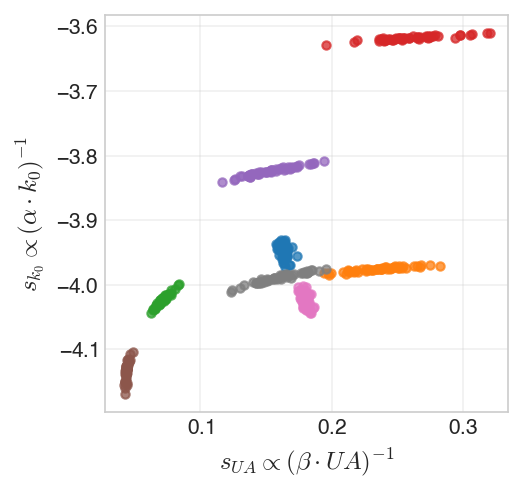

Color vs fault category:
  #1f77b4  Sc0_open_healthy
  #ff7f0e  Sc1_closed_healthy
  #2ca02c  Sc2_closed_fouling
  #d62728  Sc3_closed_decay
  #9467bd  Sc4_closed_combined
  #8c564b  Sc5_closed_saturated
  #e377c2  Sc6_open_with_fault
  #7f7f7f  Sc7_closed_drift
Saved 03_physics_features_scatter.png


In [5]:
import importlib
import jax.numpy as jnp
import cstr_sbi.summaries as summaries
from cstr_sbi.scenarios import SCENARIO_CONFIGS
from matplotlib.colors import to_hex

summaries = importlib.reload(summaries)
FEATURE_NAMES = summaries.FEATURE_NAMES
N_FEATURES = summaries.N_FEATURES
compute_summary_statistics_batch = summaries.compute_summary_statistics_batch

d_sys1 = np.load(DATA / "observations.npz", allow_pickle=True)
x_sys1 = jnp.asarray(d_sys1["x"])            # (400, 120, 4)
t_sys1 = jnp.asarray(d_sys1["t"])            # (120,) minutes
scenario_id = np.asarray(d_sys1["scenario_id"])

S29 = np.asarray(compute_summary_statistics_batch(x_sys1, t_sys1))
assert S29.shape[1] == N_FEATURES, f"expected {N_FEATURES} features, got {S29.shape[1]}"
print(f"Summary statistics: {S29.shape}, NaN={np.isnan(S29).sum()}")

scenarios = sorted(SCENARIO_CONFIGS.values(), key=lambda s: s.id)
id_to_name = {s.id: s.name for s in scenarios}

idx_ua = list(FEATURE_NAMES).index("UA_eff_proxy")
idx_k0 = list(FEATURE_NAMES).index("k0_eff_proxy")

font_kwargs = {"fontname": "Helvetica"}
cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(3.4, 3.2))
for sc in sorted(np.unique(scenario_id)):
    m = scenario_id == sc
    ax.scatter(S29[m, idx_ua], S29[m, idx_k0], s=16, alpha=0.75,
               color=cmap(sc % 10))

ax.set_xlabel(r"$s_{UA} \propto (\beta \cdot UA)^{-1}$", fontsize=12, **font_kwargs)
ax.set_ylabel(r"$s_{k_0} \propto (\alpha \cdot k_0)^{-1}$", fontsize=12, **font_kwargs)
ax.tick_params(axis='both', labelsize=10)
for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
    tick_label.set_fontname("Helvetica")
ax.grid(True, alpha=0.3)
fig.tight_layout(pad=0.4)
save_fig(fig, FIGURES / "03_physics_features_scatter")
plt.show()

print("Color vs fault category:")
for sc in sorted(np.unique(scenario_id)):
    print(f"  {to_hex(cmap(sc % 10))}  {id_to_name[sc]}")
print("Saved 03_physics_features_scatter.png")

## 3. Posterior recovery, System I (`04_posterior_recovery.png`)

Reproduces `notebooks/04_sbi_training.ipynb` \S5: $\alpha$/$\beta$ marginal
posteriors for the healthy scenario (Sc\,1) and the jacket-fouling scenario
(Sc\,2), using the cached production NSF posterior
(`results/sbi_posterior_final.pkl`) — no retraining.


/Users/simo/Repos/DarkHorse/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded cached posterior: 10000 training sims

Sc 1, healthy ($\alpha=1.00$, $\beta=1.00$):
  alpha: mean=0.994  90%CI=[0.990,0.999]  covered=False
  beta: mean=1.035  90%CI=[0.979,1.097]  covered=True


/Users/simo/Repos/DarkHorse/.venv/lib/python3.12/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2270.)
  outputs, _ = torch.triangular_solve(



Sc 2, jacket fouling ($\alpha=1.00$, $\beta=0.70$):
  alpha: mean=0.988  90%CI=[0.980,0.996]  covered=False
  beta: mean=0.728  90%CI=[0.702,0.754]  covered=False


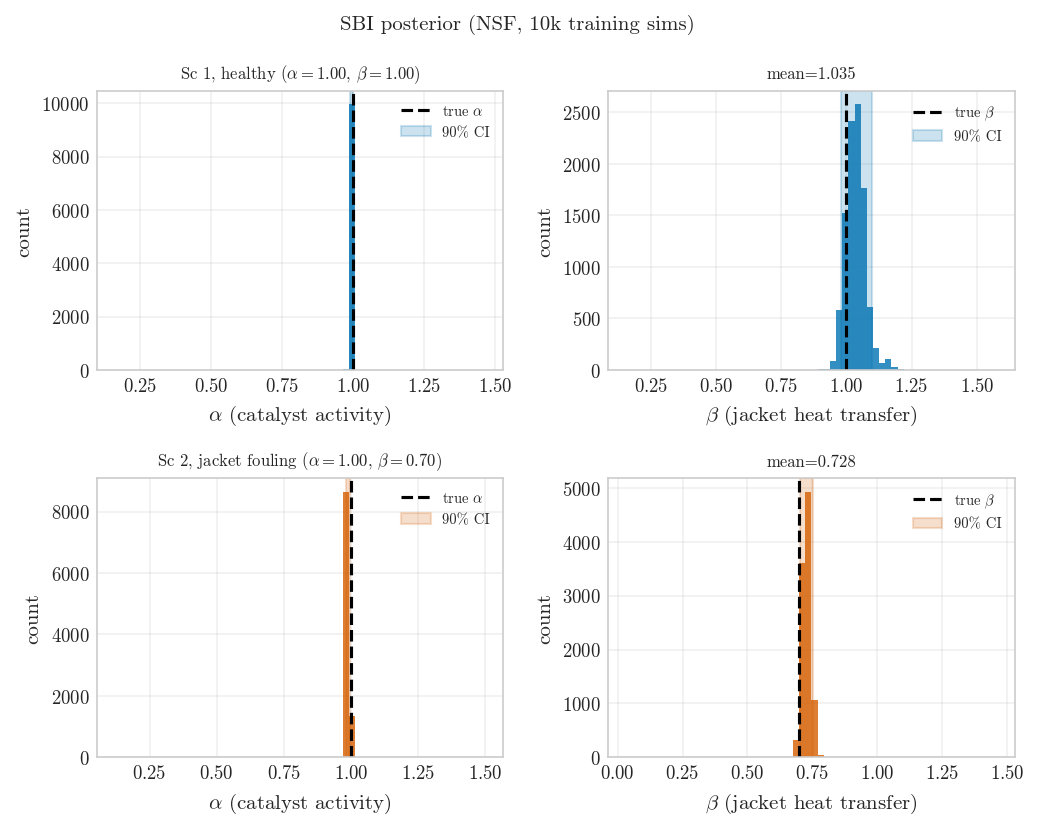

Saved 04_posterior_recovery.png


In [6]:
# Posterior recovery panels for the primary System I scenarios.

import pickle
import torch

from cstr_sbi.inference import sample_posterior

with open(RESULTS / "sbi_posterior_final.pkl", "rb") as f:
    d_final = pickle.load(f)
posterior_final = d_final["posterior"]
print(f"Loaded cached posterior: {d_final['metadata']['n_simulations']} training sims")

theta_all = d_sys1["theta"]   # (400, 4) [UA, k0, alpha, beta]
sid = scenario_id

def pick_obs(sc_id, rep=0):
    idx = np.where(sid == sc_id)[0][rep]
    return S29[idx], float(theta_all[idx, 2]), float(theta_all[idx, 3])

def simple_param_summary(values, true_value):
    ci5, ci95 = np.percentile(values, [5, 95])
    return {
        "mean": float(np.mean(values)),
        "ci_lower_90": float(ci5),
        "ci_upper_90": float(ci95),
        "coverage_90": bool(ci5 <= true_value <= ci95),
    }

N_SAMPLES = 10_000
fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.6))

for row, sc_id in enumerate([1, 2]):
    obs, alpha_t, beta_t = pick_obs(sc_id)
    samples = sample_posterior(posterior_final, obs, n_samples=N_SAMPLES)
    metrics = {
        "alpha": simple_param_summary(samples[:, 0], alpha_t),
        "beta": simple_param_summary(samples[:, 1], beta_t),
    }
    color = SBI_COLOR if row == 0 else EKF_COLOR
    tag = "healthy" if sc_id == 1 else "jacket fouling"
    sc_label = fr"Sc {sc_id}, {tag} ($\alpha={alpha_t:.2f}$, $\beta={beta_t:.2f}$)"

    ax = axes[row, 0]
    ax.hist(samples[:, 0], bins=60, color=color, alpha=0.8)
    ax.axvline(alpha_t, color="k", lw=1.5, ls="--", label=r"true $\alpha$")
    ci5, ci95 = np.percentile(samples[:, 0], [5, 95])
    ax.axvspan(ci5, ci95, alpha=0.2, color=color, label="90% CI")
    ax.set_xlabel(PARAM_LABELS_SYS1["alpha"]); ax.set_ylabel("count")
    ax.set_title(sc_label, fontsize=8)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = axes[row, 1]
    ax.hist(samples[:, 1], bins=60, color=color, alpha=0.8)
    ax.axvline(beta_t, color="k", lw=1.5, ls="--", label=r"true $\beta$")
    ci5, ci95 = np.percentile(samples[:, 1], [5, 95])
    ax.axvspan(ci5, ci95, alpha=0.2, color=color, label="90% CI")
    ax.set_xlabel(PARAM_LABELS_SYS1["beta"]); ax.set_ylabel("count")
    ax.set_title(f"mean={samples[:,1].mean():.3f}", fontsize=8)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    print(f"\n{sc_label}:")
    for name, m in metrics.items():
        print(f"  {name}: mean={m['mean']:.3f}  90%CI=[{m['ci_lower_90']:.3f},{m['ci_upper_90']:.3f}]  covered={m['coverage_90']}")

fig.suptitle("SBI posterior (NSF, 10k training sims)", fontsize=10)
fig.tight_layout()
save_fig(fig, FIGURES / "04_posterior_recovery")
plt.show()
print("Saved 04_posterior_recovery.png")

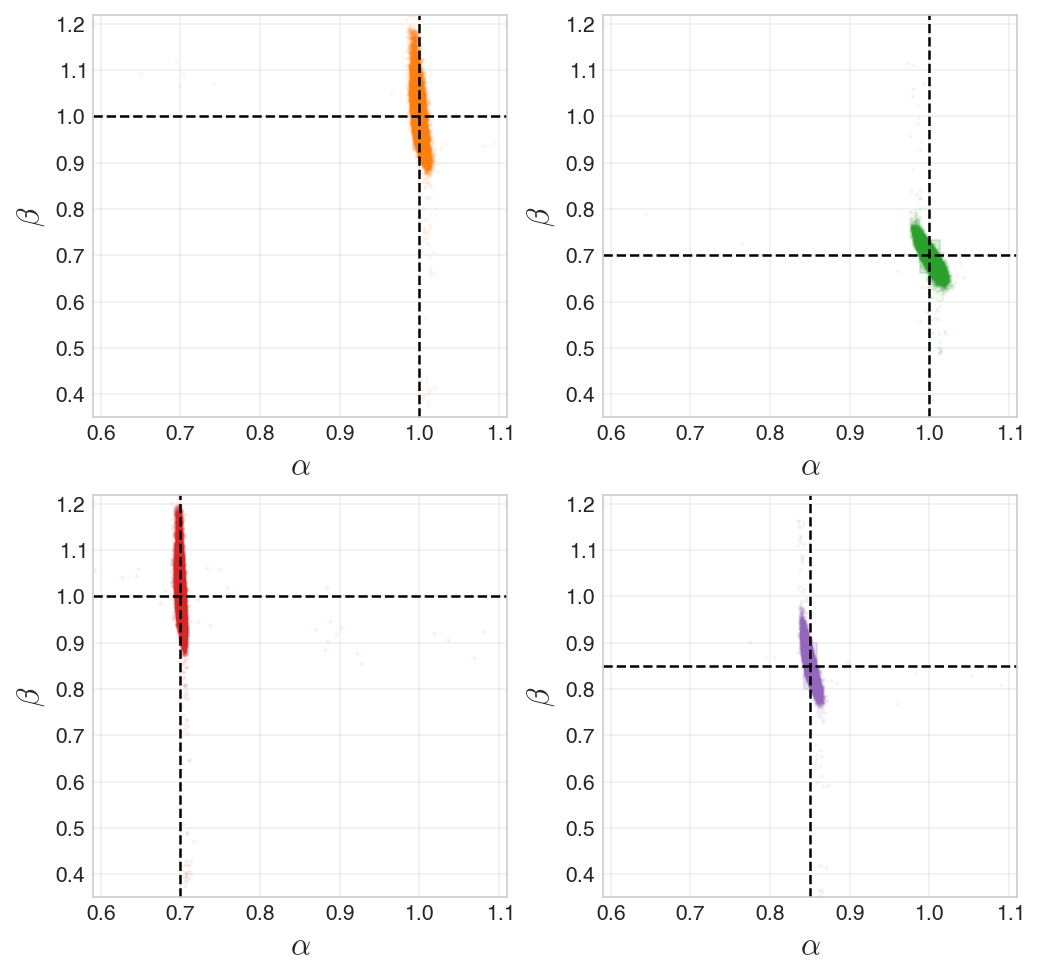

Saved 06_joint_posterior_primary.png from cached samples: (400, 1000, 2), n_samples=1000


In [7]:
# Joint posterior scatter panels for the primary System I scenarios.
# Uses cached M6 posterior samples, no resampling or retraining.

from matplotlib.patches import Rectangle
from cstr_sbi.scenarios import SCENARIO_CONFIGS as SYS1_SCENARIO_CONFIGS

m6 = np.load(RESULTS / "sbi_posteriors_m6.npz", allow_pickle=False)
all_samples_m6 = m6["samples"]
sid_m6 = m6["scenario_id"]
n_samples_m6 = int(m6["n_samples"])

scenarios_m6 = sorted(SYS1_SCENARIO_CONFIGS.values(), key=lambda s: s.id)
id_to_sc_m6 = {s.id: s for s in scenarios_m6}
primary_scenarios = [1, 2, 3, 4]

font_kwargs = {"fontname": "Helvetica"}
cmap = plt.get_cmap("tab10")
fig, axes = plt.subplots(2, 2, figsize=(6.8, 6.4), constrained_layout=True)

for ax, sc_id in zip(axes.ravel(), primary_scenarios):
    sc = id_to_sc_m6[sc_id]
    mask = sid_m6 == sc_id
    pooled = all_samples_m6[mask].reshape(-1, 2)
    color = cmap(sc_id % 10)
    alpha_ci = np.percentile(pooled[:, 0], [5, 95])
    beta_ci = np.percentile(pooled[:, 1], [5, 95])

    ax.add_patch(Rectangle(
        (alpha_ci[0], beta_ci[0]),
        alpha_ci[1] - alpha_ci[0],
        beta_ci[1] - beta_ci[0],
        facecolor=color,
        edgecolor=color,
        alpha=0.18,
        lw=1.0,
        zorder=0,
    ))
    ax.scatter(pooled[:, 0], pooled[:, 1], s=1.0, alpha=0.05, color=color, zorder=1)
    ax.axvline(sc.alpha, color="k", lw=1.2, ls="--", zorder=2)
    ax.axhline(sc.beta, color="k", lw=1.2, ls="--", zorder=2)
    #ax.axvline(0.95, color="gray", lw=0.8, ls=":", zorder=2)
    #ax.axhline(0.95, color="gray", lw=0.8, ls=":", zorder=2)

    ax.set_xlim(0.59, 1.11)
    ax.set_ylim(0.35, 1.22)
    ax.set_xlabel(r"$\alpha$", fontsize=15, **font_kwargs)
    ax.set_ylabel(r"$\beta$", fontsize=15, **font_kwargs)
    ax.tick_params(axis="both", labelsize=10)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontname("Helvetica")
    ax.grid(True, alpha=0.3)

save_fig(fig, FIGURES / "06_joint_posterior_primary")
plt.show()
print(f"Saved 06_joint_posterior_primary.png from cached samples: {all_samples_m6.shape}, n_samples={n_samples_m6}")

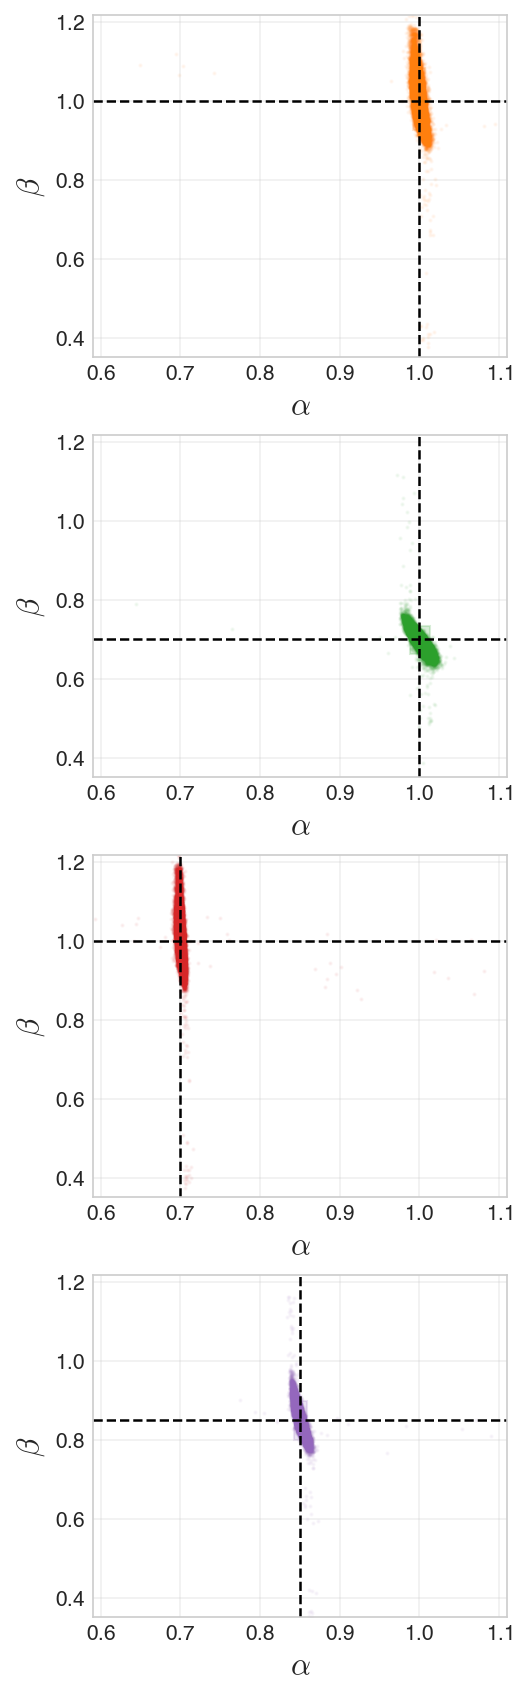

Saved 06_joint_posterior_primary_single_column.png from cached samples: (400, 1000, 2), n_samples=1000


In [8]:
# Single-column version of the primary System I joint posterior scatter panels.
# Uses the same cached M6 posterior samples, styling, limits, and 90% interval shading.

from matplotlib.patches import Rectangle
from cstr_sbi.scenarios import SCENARIO_CONFIGS as SYS1_SCENARIO_CONFIGS

m6 = np.load(RESULTS / "sbi_posteriors_m6.npz", allow_pickle=False)
all_samples_m6 = m6["samples"]
sid_m6 = m6["scenario_id"]
n_samples_m6 = int(m6["n_samples"])

scenarios_m6 = sorted(SYS1_SCENARIO_CONFIGS.values(), key=lambda s: s.id)
id_to_sc_m6 = {s.id: s for s in scenarios_m6}
primary_scenarios = [1, 2, 3, 4]

font_kwargs = {"fontname": "Helvetica"}
cmap = plt.get_cmap("tab10")
fig, axes = plt.subplots(4, 1, figsize=(3.4, 11.2), constrained_layout=True)

for ax, sc_id in zip(axes, primary_scenarios):
    sc = id_to_sc_m6[sc_id]
    mask = sid_m6 == sc_id
    pooled = all_samples_m6[mask].reshape(-1, 2)
    color = cmap(sc_id % 10)
    alpha_ci = np.percentile(pooled[:, 0], [5, 95])
    beta_ci = np.percentile(pooled[:, 1], [5, 95])

    ax.add_patch(Rectangle(
        (alpha_ci[0], beta_ci[0]),
        alpha_ci[1] - alpha_ci[0],
        beta_ci[1] - beta_ci[0],
        facecolor=color,
        edgecolor=color,
        alpha=0.18,
        lw=1.0,
        zorder=0,
    ))
    ax.scatter(pooled[:, 0], pooled[:, 1], s=1.0, alpha=0.05, color=color, zorder=1)
    ax.axvline(sc.alpha, color="k", lw=1.2, ls="--", zorder=2)
    ax.axhline(sc.beta, color="k", lw=1.2, ls="--", zorder=2)

    ax.set_xlim(0.59, 1.11)
    ax.set_ylim(0.35, 1.22)
    ax.set_xlabel(r"$\alpha$", fontsize=15, **font_kwargs)
    ax.set_ylabel(r"$\beta$", fontsize=15, **font_kwargs)
    ax.tick_params(axis="both", labelsize=10)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontname("Helvetica")
    ax.grid(True, alpha=0.3)

save_fig(fig, FIGURES / "06_joint_posterior_primary_single_column")
plt.show()
print(f"Saved 06_joint_posterior_primary_single_column.png from cached samples: {all_samples_m6.shape}, n_samples={n_samples_m6}")

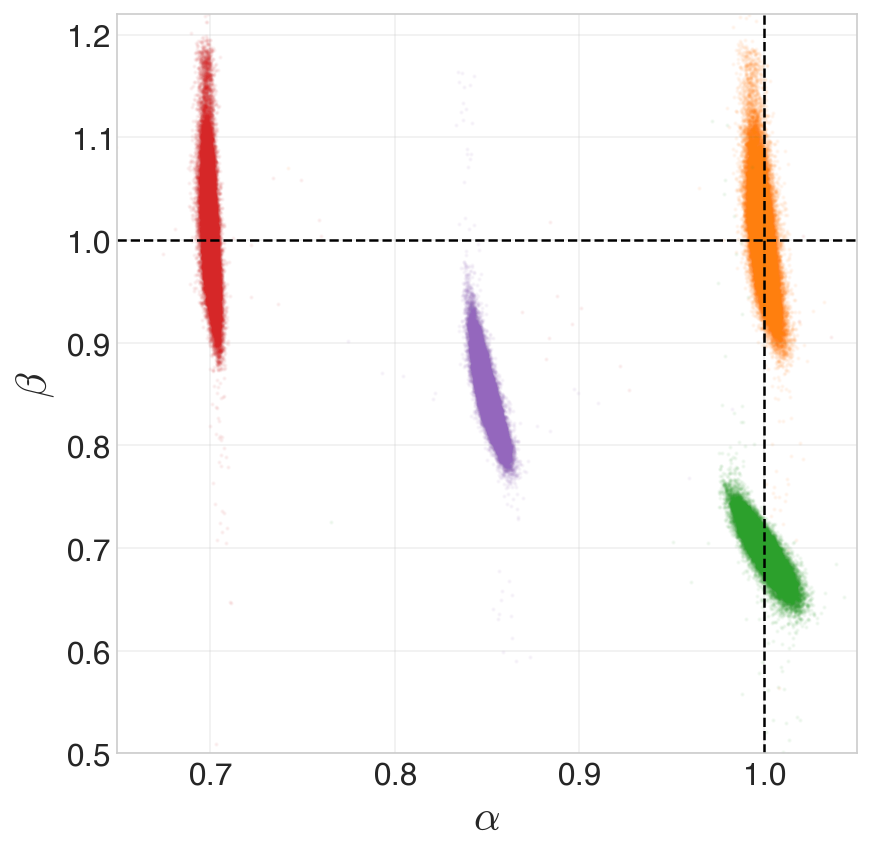

Saved 06_joint_posterior_primary_merged.png from cached samples: (400, 1000, 2), n_samples=1000


In [65]:
# the same but now all 4 panels are merged into a single one. 
# keep only the dashed lines for the 1.0 alpha and 1.0 beta reference lines, and the 90% CI rectangles for each scenario.

fig = plt.figure(figsize=(6.8, 6.4))
for sc_id in primary_scenarios: 
    sc = id_to_sc_m6[sc_id]
    mask = sid_m6 == sc_id
    pooled = all_samples_m6[mask].reshape(-1, 2)
    color = cmap(sc_id % 10)
    alpha_ci = np.percentile(pooled[:, 0], [5, 95])
    beta_ci = np.percentile(pooled[:, 1], [5, 95])

    if sc_id == 1:
        plt.axvline(sc.alpha, color="k", lw=1.2, ls="--", zorder=2)
        plt.axhline(sc.beta, color="k", lw=1.2, ls="--", zorder=2)

    plt.scatter(pooled[:, 0], pooled[:, 1], s=1.0, alpha=0.05, color=color, zorder=1)
    

plt.xlim(0.65, 1.05)
plt.ylim(0.5, 1.22)
plt.xlabel(r"$\alpha$", fontsize=20, **font_kwargs)
plt.ylabel(r"$\beta$", fontsize=20, **font_kwargs)
plt.tick_params(axis="both", labelsize=15)  

for tick_label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    tick_label.set_fontname("Helvetica")
plt.grid(True, alpha=0.3)   

# square axes box
plt.gca().set_box_aspect(1.0)

save_fig(fig, FIGURES / "06_joint_posterior_primary_merged")
plt.show()
print(f"Saved 06_joint_posterior_primary_merged.png from cached samples: {all_samples_m6.shape}, n_samples={n_samples_m6}") 


## 4. Sequential degradation tracking, System I (`10_degradation_tracking.png`)

Reproduces `notebooks/10_sequential_degradation_tracking.ipynb`: the same
production 2-D posterior (loaded above, no retraining) applied independently
to 720 sequential 60-minute windows of a 30-day $\alpha$/$\beta$ degradation
trajectory.


In [9]:
import time
from cstr_sbi.metrics import compute_crps
from cstr_sbi.scenarios import generate_degradation_stream
from cstr_sbi.summaries import compute_summary_statistics

TCRIT = 43_200.0   # 30 days in minutes
N_WINDOWS = 720

print("Generating 30-day degradation stream...")
t0_gen = time.perf_counter()
stream = generate_degradation_stream(Tcrit=TCRIT, dt_window=60.0, seed=99)
print(f"  Generated {len(stream)} windows in {time.perf_counter()-t0_gen:.1f} s")

t_days     = np.array([w["t_start"] / 60 / 24 for w in stream])
alpha_true = np.array([w["alpha_true"] for w in stream])
beta_true  = np.array([w["beta_true"]  for w in stream])

print("Computing 29-D summary statistics for all windows...")
S_stream = np.stack([
    np.asarray(compute_summary_statistics(
        jnp.asarray(stream[i]["obs"][0]), jnp.asarray(stream[i]["t"]),
    )) for i in range(N_WINDOWS)
])

N_POST = 500
print(f"Applying amortised posterior to {N_WINDOWS} windows ({N_POST} samples each)...")
t0_inf = time.perf_counter()

alpha_post_mean = np.zeros(N_WINDOWS); beta_post_mean = np.zeros(N_WINDOWS)
alpha_post_q05  = np.zeros(N_WINDOWS); alpha_post_q95 = np.zeros(N_WINDOWS)
beta_post_q05   = np.zeros(N_WINDOWS); beta_post_q95  = np.zeros(N_WINDOWS)
all_samples     = np.zeros((N_WINDOWS, N_POST, 2))

for i in range(N_WINDOWS):
    samps = sample_posterior(posterior_final, S_stream[i], n_samples=N_POST)
    all_samples[i] = samps
    alpha_post_mean[i] = samps[:, 0].mean(); beta_post_mean[i] = samps[:, 1].mean()
    alpha_post_q05[i]  = np.percentile(samps[:, 0], 5); alpha_post_q95[i] = np.percentile(samps[:, 0], 95)
    beta_post_q05[i]   = np.percentile(samps[:, 1], 5); beta_post_q95[i]  = np.percentile(samps[:, 1], 95)

t_inf = time.perf_counter() - t0_inf
alpha_mae = np.mean(np.abs(alpha_post_mean - alpha_true))
beta_mae  = np.mean(np.abs(beta_post_mean  - beta_true))
print(f"  Total inference: {t_inf:.1f} s ({t_inf/N_WINDOWS*1000:.1f} ms/window)")
print(f"  alpha MAE={alpha_mae:.4f}  beta MAE={beta_mae:.4f}")


Generating 30-day degradation stream...
  Generated 720 windows in 73.8 s
Computing 29-D summary statistics for all windows...
Applying amortised posterior to 720 windows (500 samples each)...
  Total inference: 8.3 s (11.5 ms/window)
  alpha MAE=0.0028  beta MAE=0.0197


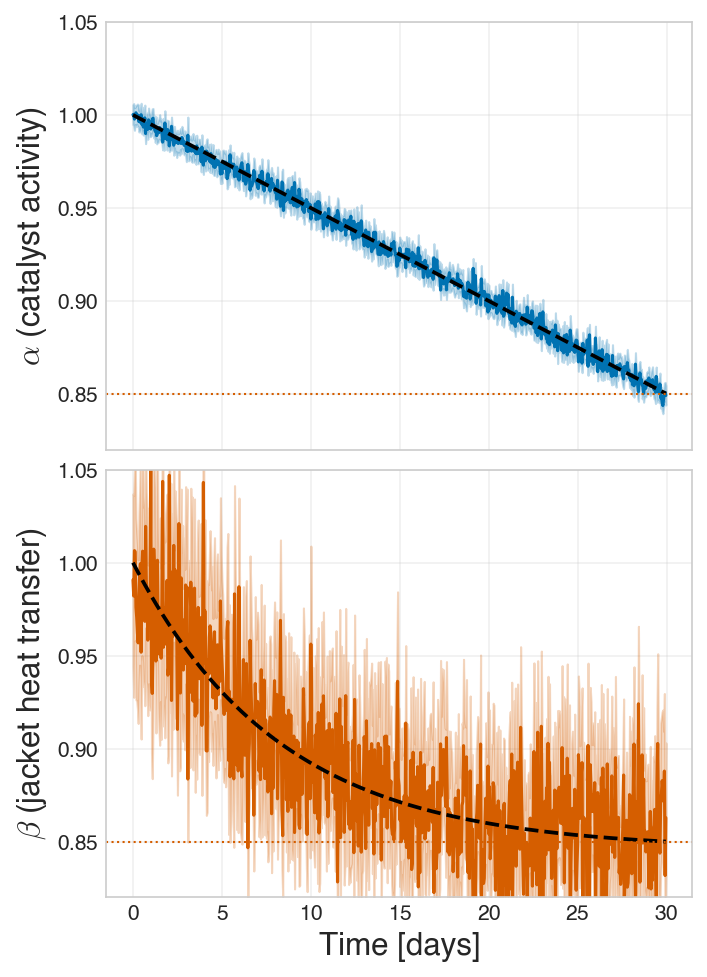

Saved 10_degradation_tracking.png


In [10]:
font_kwargs = {"fontname": "Helvetica"}
fig, axes = plt.subplots(2, 1, figsize=(4.6, 6.4), sharex=True, constrained_layout=True)

ax = axes[0]
ax.fill_between(t_days, alpha_post_q05, alpha_post_q95, alpha=0.25, color=SBI_COLOR)
ax.plot(t_days, alpha_post_mean, color=SBI_COLOR, lw=1.5)
ax.plot(t_days, alpha_true, color="k", lw=1.8, ls="--")
ax.axhline(0.85, color=EKF_COLOR, lw=1, ls=":")
ax.set_ylabel(PARAM_LABELS_SYS1["alpha"], fontsize=15, **font_kwargs)
ax.set_ylim(0.82, 1.05)
ax.grid(alpha=0.3)

ax = axes[1]
ax.fill_between(t_days, beta_post_q05, beta_post_q95, alpha=0.25, color=EKF_COLOR)
ax.plot(t_days, beta_post_mean, color=EKF_COLOR, lw=1.5)
ax.plot(t_days, beta_true, color="k", lw=1.8, ls="--")
ax.axhline(0.85, color=EKF_COLOR, lw=1, ls=":")
ax.set_xlabel("Time [days]", fontsize=15, **font_kwargs)
ax.set_ylabel(PARAM_LABELS_SYS1["beta"], fontsize=15, **font_kwargs)
ax.set_ylim(0.82, 1.05)
ax.grid(alpha=0.3)

for ax in axes:
    ax.tick_params(axis="both", labelsize=10)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontname("Helvetica")

save_fig(fig, FIGURES / "10_degradation_tracking")
plt.show()
print("Saved 10_degradation_tracking.png")

Stream classification accuracy: 86.1%
Stream macro-F1 (active classes only: ['healthy', 'fouling_dominant', 'combined']): 0.866
Per-class F1 (active classes):
  healthy                F1=0.805
  fouling_dominant       F1=0.829
  combined               F1=0.964


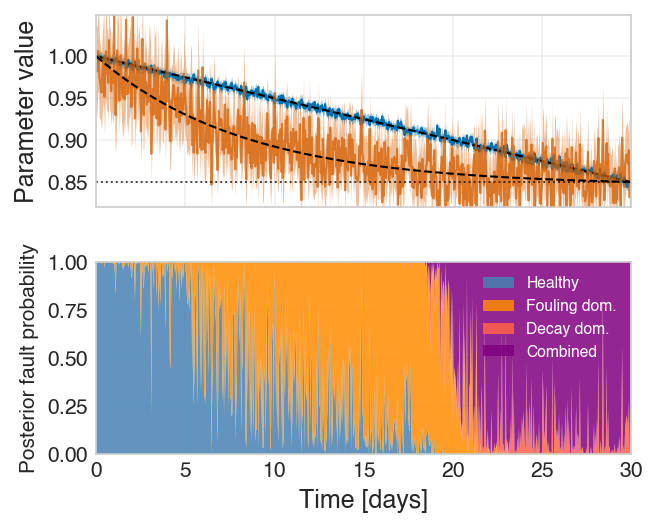

Saved 10_degradation_tracking.png


In [54]:
# Two-panel System I 30-day progressive fault figure:
# combined alpha/beta tracking, and nb11's probabilistic fault-classification timeline.
from cstr_sbi.metrics import classify_fault, compute_classification_metrics

font_kwargs = {"fontname": "Helvetica"}
legend_kwargs = {"prop": {"family": "Helvetica", "size": 7.5}}

CLASSES = ['healthy', 'fouling_dominant', 'decay_dominant', 'combined']
CLASS_LABELS = ['Healthy', 'Fouling dom.', 'Decay dom.', 'Combined']
CLASS_COLORS = ['steelblue', 'darkorange', 'tomato', 'purple']

fault_true = [w['fault_class'] for w in stream]
prob_healthy  = np.zeros(N_WINDOWS)
prob_fouling  = np.zeros(N_WINDOWS)
prob_decay    = np.zeros(N_WINDOWS)
prob_combined = np.zeros(N_WINDOWS)
fault_pred_stream = []

for i in range(N_WINDOWS):
    fc = classify_fault(all_samples[i])
    fault_pred_stream.append(fc['class'])
    prob_healthy[i]  = fc['probs']['healthy']
    prob_fouling[i]  = fc['probs']['fouling_dominant']
    prob_decay[i]    = fc['probs']['decay_dominant']
    prob_combined[i] = fc['probs']['combined']

stream_acc = np.mean(np.array(fault_pred_stream) == np.array(fault_true))
print(f'Stream classification accuracy: {stream_acc:.1%}')

cm_stream = compute_classification_metrics(fault_pred_stream, fault_true)
active_cls = [c for c in CLASSES if any(f == c for f in fault_true)]
active_f1s = [cm_stream['per_class_f1'].get(c, 0.0) for c in active_cls]
active_macro = float(np.mean(active_f1s)) if active_f1s else 0.0
print(f"Stream macro-F1 (active classes only: {active_cls}): {active_macro:.3f}")
print('Per-class F1 (active classes):')
for cls in active_cls:
    f1 = cm_stream['per_class_f1'].get(cls, 0.0)
    print(f'  {cls:<22} F1={f1:.3f}')

fig, axes = plt.subplots(2, 1, figsize=(4.6, 4.2), sharex=True, gridspec_kw={"hspace": 0.04})

ax = axes[0]
ax.fill_between(t_days, alpha_post_q05, alpha_post_q95, alpha=0.4, color=SBI_COLOR, linewidth=0)
ax.plot(t_days, alpha_post_mean, color=SBI_COLOR, lw=1.0, label=r'SBI $\alpha$')
ax.plot(t_days, alpha_true, color='k', lw=1.0, ls='--', label=r'true $\alpha$')
ax.fill_between(t_days, beta_post_q05, beta_post_q95, alpha=0.4, color=EKF_COLOR, linewidth=0)
ax.plot(t_days, beta_post_mean, color=EKF_COLOR, alpha=0.75, lw=1.0, label=r'SBI $\beta$')
ax.plot(t_days, beta_true, color='k', lw=1.0, ls='--', label=r'true $\beta$')
ax.axhline(0.85, color=OI[0], lw=0.9, ls=':', alpha=0.75, label='threshold')
ax.set_ylabel('Parameter value', fontsize=12, **font_kwargs)
ax.set_xlim(0, 30)
# add y axis ticks 
ax.set_yticks([0.85, 0.90, 0.95, 1.00])
ax.set_ylim(0.82, 1.05)
ax.set_box_aspect(0.36)
ax.grid(alpha=0.3)
#ax.legend(loc='upper right', ncol=2, **legend_kwargs)

# Top panel of nb11's "Probabilistic fault classification timeline (Sc8 -- 30-day degradation)".
ax = axes[1]
ax.stackplot(t_days, prob_healthy, prob_fouling, prob_decay, prob_combined,
             labels=CLASS_LABELS, colors=CLASS_COLORS, alpha=0.85)
ax.set_ylabel('Posterior fault probability', fontsize=10, **font_kwargs)
ax.set_xlabel("Time [days]", fontsize=12, **font_kwargs)
ax.set_xlim(0, 30)
ax.set_ylim(0, 1)
ax.set_box_aspect(0.36)
#ax.set_title('Probabilistic fault classification timeline (Sc8 -- 30-day degradation)', fontsize=8.5, **font_kwargs)
ax.grid(alpha=0.2)

transition_fouling = t_days[np.array(fault_true) == 'fouling_dominant']
transition_combined = t_days[np.array(fault_true) == 'combined']
#if len(transition_fouling) > 0:
##    ax.axvline(transition_fouling[0], color='k', lw=1., ls='--', alpha=0.6,
##               #label=f'True: healthy -> fouling_dominant (day {transition_fouling[0]:.1f})'
##               )
#if len(transition_combined) > 0:
##    ax.axvline(transition_combined[0], color='k', lw=1., ls='--', alpha=0.6,
##               #label=f'True: fouling_dominant -> combined (day {transition_combined[0]:.1f})'
##               )
ax.legend(loc='upper right', labelcolor='white', **legend_kwargs)

for ax in axes:
    ax.tick_params(axis="both", labelsize=10)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontname("Helvetica")

save_fig(fig, FIGURES / "10_degradation_tracking")
plt.show()
print("Saved 10_degradation_tracking.png")

## 5. Fault classification confusion matrix, System II (`nb31_confusion_matrix.png`)

Loads the final, already-computed classification result from
`results/31_classification_summary.json` (produced by
`notebooks/31_wu2003_fault_classification.ipynb`: 14 closed-loop scenarios x 30
replicates x 200 posterior draws, calibrated seed-4 S-B posterior) rather than
recomputing the full posterior-sampling sweep here.


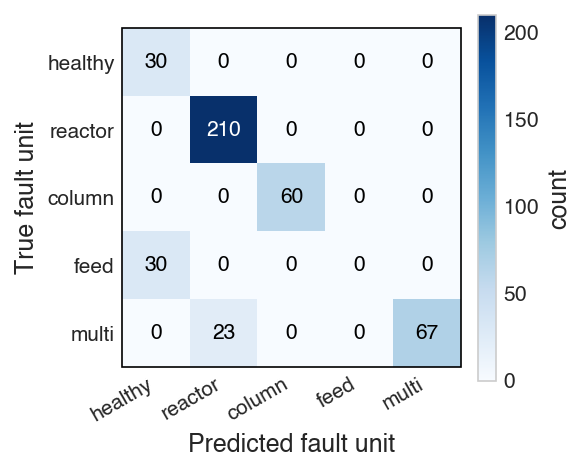

Saved nb31_confusion_matrix.png — accuracy=0.874, macro-F1=0.694


In [11]:
import json
from matplotlib.patches import Rectangle

with open(RESULTS / "31_classification_summary.json") as f:
    clf_summary = json.load(f)

cm          = np.array(clf_summary["confusion_matrix"])
class_names = clf_summary["class_names"]
accuracy    = clf_summary["accuracy"]
macro_f1    = clf_summary["macro_f1"]
n_sc, n_reps = clf_summary["n_scenarios"], clf_summary["n_replicates_per_scenario"]

font_kwargs = {"fontname": "Helvetica"}
fig, ax = plt.subplots(figsize=(3.8, 3.4), constrained_layout=True)
im = ax.imshow(cm, cmap="Blues", aspect="equal")
ax.set_aspect("equal", adjustable="box")
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=30, ha="right", fontsize=10, **font_kwargs)
ax.set_yticks(range(len(class_names)))
ax.set_yticklabels(class_names, fontsize=10, **font_kwargs)
ax.set_xlabel("Predicted fault unit", fontsize=12, **font_kwargs)
ax.set_ylabel("True fault unit", fontsize=12, **font_kwargs)
ax.grid(False, which="both")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.add_patch(Rectangle(
    (-0.5, -0.5), cm.shape[1], cm.shape[0],
    fill=False, edgecolor="black", linewidth=0.8, clip_on=False,
))

for i in range(len(class_names)):
    for j in range(len(class_names)):
        val = cm[i, j]
        ax.text(
            j, i, str(val), ha="center", va="center",
            color="white" if val > cm.max() / 2 else "black",
            fontsize=10, **font_kwargs,
        )

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.tick_params(labelsize=10)
for tick_label in cbar.ax.get_yticklabels():
    tick_label.set_fontname("Helvetica")
cbar.set_label("count", fontsize=12, **font_kwargs)
cbar.ax.grid(False, which="both")

save_fig(fig, FIGURES / "nb31_confusion_matrix")
plt.show()
print(f"Saved nb31_confusion_matrix.png — accuracy={accuracy:.3f}, macro-F1={macro_f1:.3f}")

## 6. Fisher information matrices, System II (`nb23_fim_heatmap_single.png`)

Recomputes the $5\times5$ FIM ($I = J^\top \Sigma^{-1} J$) at the nominal operating
point for both control structures (S-B, S-A), reproducing
`notebooks/23_wu2003_summary_statistics.ipynb` \S7 **exactly**: $\Sigma$ is the
per-feature variance of the real W1 (healthy) replicates in the cached dataset
(`data/wu2003_observations.npz`), not a freshly-simulated noise draw — this is
the same noise-calibration that produces the $+0.901$ off-diagonal number quoted
in the running text (Section~\ref{sec:wu_identifiability}); a differently-seeded
noise draw reproduces the same sign/magnitude only approximately (see
`scripts/fim_utils.py`'s docstring and the project handoff notes on this point).
Physics-only finite-difference computation — no SBI training involved.

Both panels are needed to support the caption's claim ("both structures show
near-zero $T_r$-channel contributions...") — the on-disk file this notebook
replaces only contained the S-B panel.


In [12]:
from cstr_sbi.recycle.simulator import load_dataset, nominal_warm_start as recycle_warm_start, deterministic_window
from cstr_sbi.recycle.summaries import compute_summaries, channel_summaries, physics_features
from cstr_sbi.recycle.scenarios import list_closed_loop
from cstr_sbi.recycle.physics import (
    simulate_trajectory_explicit_jit, extract_observations_explicit,
    NOMINAL_CTRL_SA, NOMINAL_CTRL_SB, NOMINAL_INLET, PARAM_NAMES as PARAM_NAMES_SYS2,
)

# --- Reproduce nb23 Section 7 exactly: dataset-derived (real replicate) noise
# covariance, not a freshly-simulated noise draw (see markdown above). ---
dataset = load_dataset(DATA / "wu2003_observations.npz")
obs_sa, obs_sb = dataset["observations_sa"], dataset["observations_sb"]
labels, t_h = dataset["labels"], dataset["t_h"]
sc_labels = labels["scenario_name"].values

y0_sa_fim = recycle_warm_start("S-A")
y0_sb_fim = recycle_warm_start("S-B")
cl_configs = list_closed_loop()

print("Re-simulating 16 scenarios for 12-channel raw trajectories (~60s)...")
raw_det_sa, raw_det_sb = {}, {}
t_grid = None
for sc in cl_configs:
    t_s, r_sa = deterministic_window(sc, structure="S-A", y0=y0_sa_fim)
    _, r_sb = deterministic_window(sc, structure="S-B", y0=y0_sb_fim)
    raw_det_sa[sc.name] = np.asarray(r_sa)
    raw_det_sb[sc.name] = np.asarray(r_sb)
    if t_grid is None:
        t_grid = np.asarray(t_s)
print("Done.")

n_sb = compute_summaries(raw_det_sb[cl_configs[0].name], "S-B", t_grid).shape[0]
X_sb_rep = np.zeros((len(labels), n_sb), dtype=np.float32)
for i in range(len(labels)):
    ch_stats = channel_summaries(obs_sb[i], t_h)
    phys = physics_features(raw_det_sb[sc_labels[i]], t_grid)
    X_sb_rep[i] = np.concatenate([ch_stats, phys])
nan_mask = np.isnan(X_sb_rep).any(axis=1)
X_clean, labels_clean = X_sb_rep[~nan_mask], labels[~nan_mask].reset_index(drop=True)

n_sa = compute_summaries(raw_det_sa[cl_configs[0].name], "S-A", t_grid).shape[0]
X_sa_rep = np.zeros((len(labels), n_sa), dtype=np.float32)
for i in range(len(labels)):
    ch_stats = channel_summaries(obs_sa[i], t_h)
    phys = physics_features(raw_det_sa[sc_labels[i]], t_grid)
    X_sa_rep[i] = np.concatenate([ch_stats, phys])
xa_nan_mask = np.isnan(X_sa_rep).any(axis=1)
X_sa_clean, labels_sa_clean = X_sa_rep[~xa_nan_mask], labels[~xa_nan_mask].reset_index(drop=True)

print(f"X_clean (S-B): {X_clean.shape}, X_sa_clean (S-A): {X_sa_clean.shape}")

THETA_NOM = np.array([1.0, 1.0, 1.0, 1.0, 0.90], dtype=np.float32)
EPS_FIM   = np.array([0.02, 0.02, 0.02, 0.02, 0.01])

def sim_summary(theta_np, y0, ctrl, structure, rng_seed=0):
    th = jnp.array(theta_np, dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit_jit(
        th, NOMINAL_INLET, ctrl, jnp.array(y0), t_final=2.0, n_save=120, rtol=1e-3, atol=1e-5
    )
    raw = np.asarray(extract_observations_explicit(ys, th, ctrl))
    t_h_loc = np.asarray(ts)
    rng = np.random.default_rng(rng_seed)
    sc = np.maximum(np.max(np.abs(raw), axis=0), 1e-6)
    return compute_summaries(raw + rng.normal(0, 0.003 * sc, raw.shape), structure, t_h_loc)

def compute_fim_dataset_sigma(X_clean_local, labels_clean_local, y0, ctrl, structure):
    """FIM = J^T Sigma^-1 J, Sigma from real W1 replicate variance (nb23 methodology)."""
    w1_mask = labels_clean_local["scenario_name"] == "W1_healthy"
    Sigma_diag = np.var(X_clean_local[w1_mask], axis=0) + 1e-12
    n_feat, n_params = X_clean_local.shape[1], len(THETA_NOM)
    J = np.zeros((n_feat, n_params))
    for j, eps in enumerate(EPS_FIM):
        th_p = THETA_NOM.copy(); th_p[j] += eps
        th_m = THETA_NOM.copy(); th_m[j] -= eps
        s_p = sim_summary(th_p, y0, ctrl, structure, rng_seed=j * 10 + 1)
        s_m = sim_summary(th_m, y0, ctrl, structure, rng_seed=j * 10 + 2)
        J[:, j] = (s_p - s_m) / (2 * eps)
    return J.T @ (J / Sigma_diag[:, None])

print("Computing S-B FIM (dataset-calibrated noise covariance)...")
FIM_sb = compute_fim_dataset_sigma(X_clean, labels_clean, y0_sb_fim, NOMINAL_CTRL_SB, "S-B")
print("Computing S-A FIM (dataset-calibrated noise covariance)...")
FIM_sa = compute_fim_dataset_sigma(X_sa_clean, labels_sa_clean, y0_sa_fim, NOMINAL_CTRL_SA, "S-A")

def _normalise(FIM):
    D = np.sqrt(np.diag(FIM)); D_safe = np.where(D > 0, D, 1.0)
    return FIM / np.outer(D_safe, D_safe)

FIM_sb_norm, FIM_sa_norm = _normalise(FIM_sb), _normalise(FIM_sa)

alpha_idx = list(PARAM_NAMES_SYS2).index("alpha")
betar_idx = list(PARAM_NAMES_SYS2).index("beta_r")
print(f"S-B off-diagonal (alpha, beta_r) = {FIM_sb_norm[alpha_idx, betar_idx]:+.3f}")
print(f"S-A off-diagonal (alpha, beta_r) = {FIM_sa_norm[alpha_idx, betar_idx]:+.3f}")
print(f"S-B I_alpha/I_beta_r = {FIM_sb[alpha_idx,alpha_idx]/max(FIM_sb[betar_idx,betar_idx],1e-30):.1f}x")


Re-simulating 16 scenarios for 12-channel raw trajectories (~60s)...
Done.


/Users/simo/Repos/DarkHorse/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/simo/Repos/DarkHorse/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


X_clean (S-B): (420, 66), X_sa_clean (S-A): (420, 72)
Computing S-B FIM (dataset-calibrated noise covariance)...
Computing S-A FIM (dataset-calibrated noise covariance)...
S-B off-diagonal (alpha, beta_r) = +0.917
S-A off-diagonal (alpha, beta_r) = +0.329
S-B I_alpha/I_beta_r = 0.4x


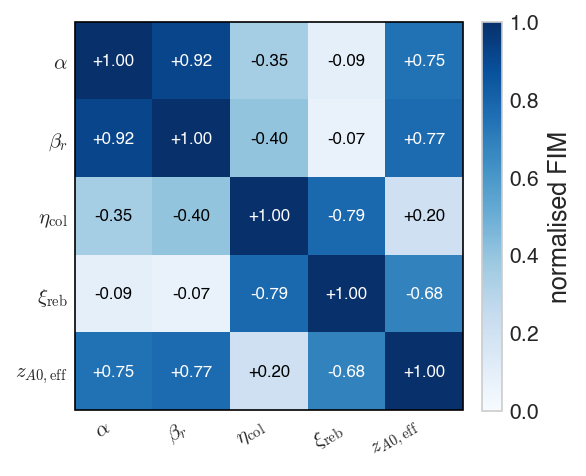

Saved nb23_fim_heatmap_single.png (S-B panel only)


In [13]:
from matplotlib.patches import Rectangle

param_labels = [PARAM_LABELS_SYS2[p] for p in PARAM_NAMES_SYS2]
font_kwargs = {"fontname": "Helvetica"}

fig, ax = plt.subplots(figsize=(3.8, 3.4), constrained_layout=True)
im = ax.imshow(np.abs(FIM_sb_norm), cmap="Blues", vmin=0, vmax=1, aspect="equal")
ax.set_aspect("equal", adjustable="box")
ax.set_xticks(range(len(param_labels)))
ax.set_xticklabels(param_labels, rotation=30, ha="right", fontsize=10, **font_kwargs)
ax.set_yticks(range(len(param_labels)))
ax.set_yticklabels(param_labels, fontsize=10, **font_kwargs)
ax.grid(False, which="both")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.add_patch(Rectangle(
    (-0.5, -0.5), FIM_sb_norm.shape[1], FIM_sb_norm.shape[0],
    fill=False, edgecolor="black", linewidth=0.8, clip_on=False,
))

for i in range(FIM_sb_norm.shape[0]):
    for j in range(FIM_sb_norm.shape[1]):
        val = FIM_sb_norm[i, j]
        ax.text(
            j, i, f"{val:+.2f}", ha="center", va="center",
            color="white" if abs(val) > 0.6 else "black",
            fontsize=8, **font_kwargs,
        )

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.tick_params(labelsize=10)
for tick_label in cbar.ax.get_yticklabels():
    tick_label.set_fontname("Helvetica")
cbar.set_label("normalised FIM", fontsize=12, **font_kwargs)
cbar.ax.grid(False, which="both")

save_fig(fig, FIGURES / "nb23_fim_heatmap_single")
plt.show()
print("Saved nb23_fim_heatmap_single.png (S-B panel only)")

## 7. Summary

All figures referenced by `docs/Manuscript/main.tex` (besides Figure 1,
`system.jpeg`) regenerated above in one consistent style.


In [14]:
expected = [
    "nb21_cl_vs_ol_masking.png",
    "03_physics_features_scatter.png",
    "04_posterior_recovery.png",
    "10_degradation_tracking.png",
    "nb31_confusion_matrix.png",
    "nb23_fim_heatmap_single.png",
]
print("Manuscript figures (excl. Figure 1 / system.jpeg):\n")
for name in expected:
    p = FIGURES / name
    status = f"{p.stat().st_size/1024:7.1f} KB" if p.exists() else "MISSING"
    print(f"  {name:35s}  {status}")


Manuscript figures (excl. Figure 1 / system.jpeg):

  nb21_cl_vs_ol_masking.png              167.9 KB
  03_physics_features_scatter.png         71.8 KB
  04_posterior_recovery.png              138.5 KB
  10_degradation_tracking.png            437.2 KB
  nb31_confusion_matrix.png               82.4 KB
  nb23_fim_heatmap_single.png             93.7 KB


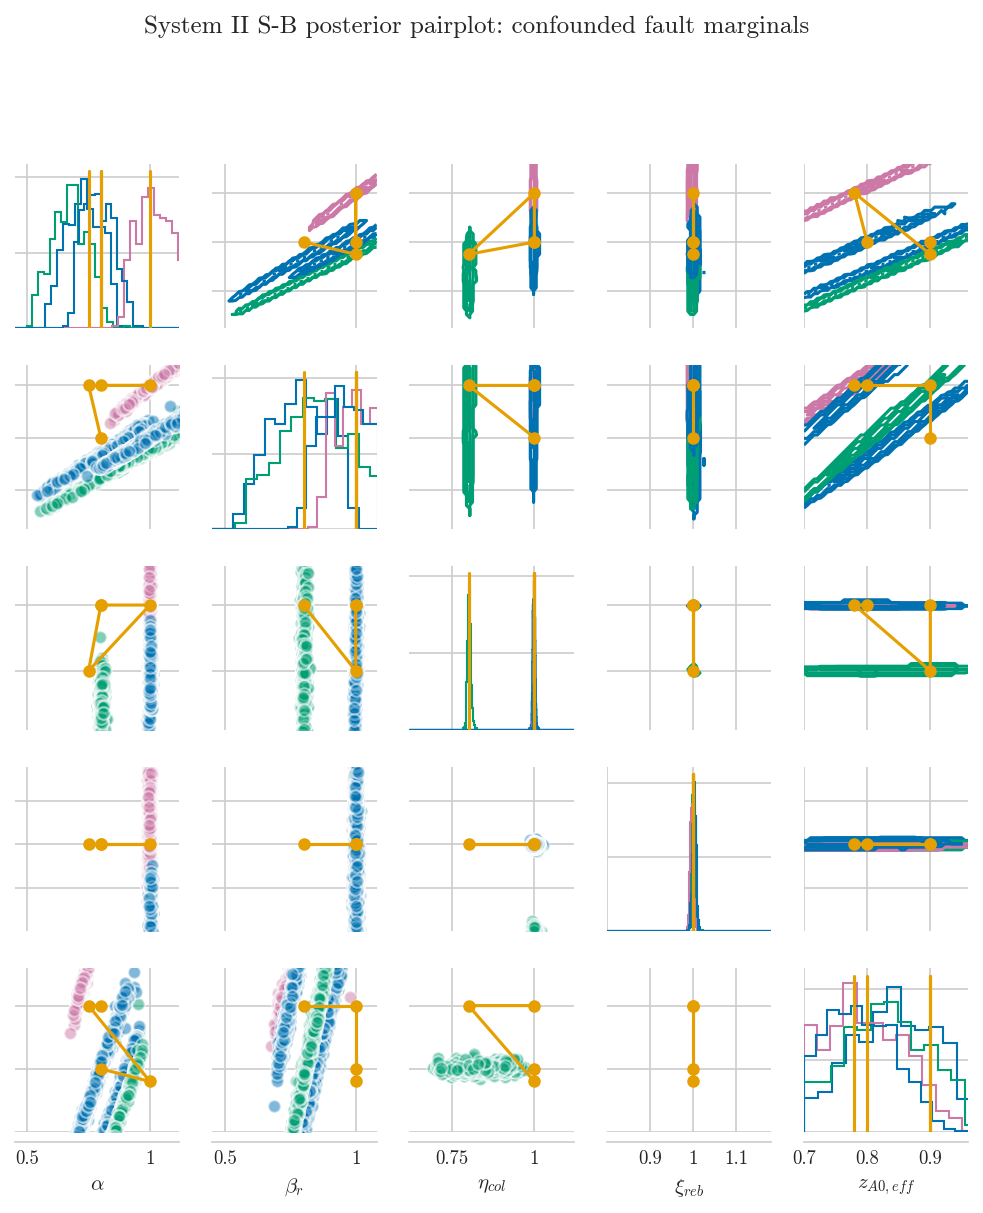

Posterior source: seed=4, N_TRAIN=15000
W11_reactor_combined     alpha vs beta_r: corr=+0.996, samples=720, truth=(0.800, 0.800)
W12_snowball_compound    alpha vs eta_col: corr=+0.132, samples=720, truth=(0.750, 0.800)
W10_feed_impurity        alpha vs z_A0_eff: corr=+0.992, samples=720, truth=(1.000, 0.780)
W13_cat_feed             alpha vs z_A0_eff: corr=+0.993, samples=720, truth=(0.800, 0.800)
Saved systemII_confounded_marginals_pairplot.png


In [15]:
# System II multi-scenario posterior pairplot for the main confounded marginals.
# Uses sbi.analysis.pairplot over all five fault parameters, with lightweight sampling.

import sys
import pathlib
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch

ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)
SBI_LOGS = ROOT / "sbi-logs"

from sbi.analysis import pairplot
from cstr_sbi.style import save_fig, OI
from cstr_sbi.recycle.physics import PARAM_NAMES as PARAM_NAMES_SYS2_RAW
from cstr_sbi.recycle.scenarios import get_scenario
from cstr_sbi.recycle.simulator import nominal_warm_start, deterministic_window, noisy_replicates
from cstr_sbi.recycle.summaries import compute_summaries

PAIRPLOT_CASES = [
    ("W11_reactor_combined", 0, 1, r"W11: $\alpha$-$\beta_r$"),
    ("W12_snowball_compound", 0, 2, r"W12: $\alpha$-$\eta_{col}$"),
    ("W10_feed_impurity", 0, 4, r"W10: $\alpha$-$z_{A0}$"),
    ("W13_cat_feed", 0, 4, r"W13: $\alpha$-$z_{A0}$"),
]
N_PAIRPLOT_REPLICATES = 12
N_PAIRPLOT_SAMPLES_PER_REP = 60

with open(SBI_LOGS / "wu2003_posterior_sb.pkl", "rb") as f:
    sb_data_pair = pickle.load(f)
posterior_sb_pair = sb_data_pair["posterior"]
y0_sb_pair = nominal_warm_start("S-B")

case_samples_pair = []
case_truths_pair = []
case_labels_pair = []
rng_pair = np.random.default_rng(20260809)
torch.manual_seed(20260809)

for case_idx, (scenario_key, _, _, label) in enumerate(PAIRPLOT_CASES):
    sc_pair = get_scenario(scenario_key)
    truth_pair = np.asarray(sc_pair.theta(), dtype=np.float32)
    t_pair, raw_pair = deterministic_window(sc_pair, structure="S-B", y0=y0_sb_pair)
    replicates_pair = noisy_replicates(
        np.asarray(raw_pair),
        n_replicates=N_PAIRPLOT_REPLICATES,
        rng=rng_pair,
        noise_pct=0.003,
    )

    scenario_samples = []
    for rep in replicates_pair:
        x_obs = torch.as_tensor(
            compute_summaries(rep, "S-B", np.asarray(t_pair)),
            dtype=torch.float32,
        )
        with torch.no_grad():
            samp = posterior_sb_pair.posterior_estimator.sample(
                (N_PAIRPLOT_SAMPLES_PER_REP,),
                condition=x_obs.reshape(1, -1),
            )
        scenario_samples.append(samp.reshape(-1, len(PARAM_NAMES_SYS2_RAW)).cpu().numpy())

    samples_case = np.concatenate(scenario_samples, axis=0)
    samples_case = samples_case[np.isfinite(samples_case).all(axis=1)]
    case_samples_pair.append(samples_case)
    case_truths_pair.append(truth_pair)
    case_labels_pair.append(label)

param_labels_pair = [
    r"$\alpha$",
    r"$\beta_r$",
    r"$\eta_{col}$",
    r"$\xi_{reb}$",
    r"$z_{A0,eff}$",
]
plot_limits_pair = [
    [0.45, 1.12],
    [0.45, 1.08],
    [0.62, 1.12],
    [0.80, 1.18],
    [0.70, 0.96],
]
case_colors_pair = [OI[1], OI[2], OI[3], OI[6]]

fig, axes = pairplot(
    case_samples_pair,
    limits=plot_limits_pair,
    labels=param_labels_pair,
    points=np.asarray(case_truths_pair),
    figsize=(8.2, 8.2),
    diag="hist",
    upper="contour",
    lower="scatter",
    diag_kwargs={"bins": 24, "alpha": 0.38},
    lower_kwargs={"s": 2.0, "alpha": 0.06, "rasterized": True},
    upper_kwargs={"linewidths": 0.9},
    fig_kwargs={
        "samples_colors": case_colors_pair,
        "samples_labels": case_labels_pair,
        "points_colors": case_colors_pair,
    },
)
fig.suptitle("System II S-B posterior pairplot: confounded fault marginals", fontsize=12, y=1.02)
save_fig(fig, FIGURES / "systemII_confounded_marginals_pairplot")
plt.show()

print(f"Posterior source: seed={sb_data_pair.get('selected_seed')}, N_TRAIN={sb_data_pair.get('N_TRAIN')}")
for (scenario_key, i, j, label), samples_case, truth_pair in zip(PAIRPLOT_CASES, case_samples_pair, case_truths_pair):
    corr = np.corrcoef(samples_case[:, i], samples_case[:, j])[0, 1]
    print(
        f"{scenario_key:24s} {PARAM_NAMES_SYS2_RAW[i]} vs {PARAM_NAMES_SYS2_RAW[j]}: "
        f"corr={corr:+.3f}, samples={samples_case.shape[0]}, "
        f"truth=({truth_pair[i]:.3f}, {truth_pair[j]:.3f})"
    )
print("Saved systemII_confounded_marginals_pairplot.png")

## 9. Sequential degradation tracking, System II (`nb27_sequential_tracking.png`)

Showcases the manuscript's System~II 30-day tracking result
(Section~\ref{sec:wu_sequential}, "30-Day Sequential Degradation Tracking"):
SBI applied independently to 360 consecutive 2-hour windows (no state carried
between windows) vs. an augmented EKF with privileged access to the raw,
unaggregated trajectory (recursive state). Reproduces
`notebooks/27_wu2003_sequential_tracking.ipynb` \S\S2-6. Unlike the sections
above, no cached artifact exists for this pipeline, so it recomputes the full
360-window sweep from scratch (sequential window generation, amortised SBI
inference with the calibrated S-B posterior, and an EKF with
`jax.jacfwd`-jitted Jacobians — the same fix documented in `nb26`/`nb27` that
avoids the >12h cost of manual finite differences over 360x120 timesteps).
Expect a few minutes end-to-end. The y-axes are left to autoscale rather than
fixed, per a bug already found and fixed in `nb27`: a hardcoded range there
had clipped most of the SBI $\beta_r$ divergence out of the visible plot.


In [16]:
# Sequential 30-day, 360-window degradation stream (System II, S-B). Self-contained:
# own imports/paths, independent of earlier cells.

import sys, pathlib, pickle, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import jax
import jax.numpy as jnp

ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)
SBI_LOGS = ROOT / "sbi-logs"

from cstr_sbi.style import save_fig, OI, SBI_COLOR, EKF_COLOR, PARAM_LABELS_SYS2
from cstr_sbi.recycle.physics import (
    NOMINAL_CTRL_SB, NOMINAL_INLET, simulate_trajectory_explicit,
    extract_observations_explicit, T_SP, T_J_NOM, recycle_rhs_explicit,
    column_qss, F0_NOM, F_R_NOM,
)
from cstr_sbi.recycle.summaries import compute_summaries, SB_INDICES
from cstr_sbi.recycle.simulator import nominal_warm_start as recycle_warm_start_seq

with open(SBI_LOGS / "wu2003_posterior_sb.pkl", "rb") as f:
    posterior_sb_seq = pickle.load(f)["posterior"]
print("Loaded S-B (hand-crafted, 66-D) posterior for sequential tracking.")

CNN_PKL_SEQ = SBI_LOGS / "wu2003_posterior_sb_cnn.pkl"
with open(CNN_PKL_SEQ, "rb") as f:
    posterior_cnn_seq = pickle.load(f)["posterior"]
print(f"Loaded CNN-embedding (raw-trajectory) S-B posterior ({CNN_PKL_SEQ.name}).")

# 30 days = 360 consecutive 2h windows (12 windows/day)
N_DAYS_SEQ = 30
N_WINDOWS_SEQ = N_DAYS_SEQ * 12
t_days_seq = np.arange(N_WINDOWS_SEQ) * (2 / 24)

# Catalyst decay: linear 1.0 -> 0.65. Jacket fouling: Kern-Seaton, 1.0 -> ~0.90.
# eta_col, xi_reb, z_A0_eff are held at their healthy nominal values throughout
# (matching nb27/nb32's own scenario definition) -- see the discussion below on
# whether/how those three could also be tracked here.
alpha_true_seq = np.clip(1.0 - (1.0 - 0.65) * t_days_seq / N_DAYS_SEQ, 0.65, 1.0)
t_hours_seq = t_days_seq * 24.0
beta_r_true_seq = np.clip(1.0 / (1.0 + 1.5e-4 * t_hours_seq), 0.90, 1.0)
theta_true_seq = np.stack([
    alpha_true_seq, beta_r_true_seq,
    np.ones(N_WINDOWS_SEQ), np.ones(N_WINDOWS_SEQ), np.full(N_WINDOWS_SEQ, 0.90),
], axis=1)

print(f"Simulating {N_WINDOWS_SEQ} sequential 2h windows (~1 min, incl. JIT warmup)...")
y0_sb_seq = recycle_warm_start_seq("S-B")
rng_obs_seq = np.random.default_rng(20260701)
ctrl_seq = jnp.array(NOMINAL_CTRL_SB)
y_current_seq = jnp.array(y0_sb_seq)

raw_windows_seq = []
t_h_window_seq = None
t0 = time.time()
for win_i in range(N_WINDOWS_SEQ):
    theta_j = jnp.array(theta_true_seq[win_i], dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit(
        theta_j, NOMINAL_INLET, ctrl_seq, y_current_seq, t_final=2.0, n_save=120
    )
    raw_np = np.asarray(extract_observations_explicit(ys, theta_j, ctrl_seq))
    if t_h_window_seq is None:
        t_h_window_seq = np.asarray(ts)
    scale = np.maximum(np.max(np.abs(raw_np), axis=0), 1e-6)
    raw_windows_seq.append(raw_np + rng_obs_seq.normal(0, 0.003 * scale, raw_np.shape))
    y_current_seq = ys[-1]
    if (win_i + 1) % 120 == 0:
        print(f"  window {win_i+1}/{N_WINDOWS_SEQ} ({time.time()-t0:.0f}s)")
raw_windows_seq = np.stack(raw_windows_seq)
print(f"Done in {time.time()-t0:.0f}s. raw_windows: {raw_windows_seq.shape}")

summaries_seq = np.stack([
    compute_summaries(raw_windows_seq[i], "S-B", t_h_window_seq) for i in range(N_WINDOWS_SEQ)
])
print(f"Summaries: {summaries_seq.shape}, NaN rows: {np.isnan(summaries_seq).any(axis=1).sum()}")


Loaded S-B (hand-crafted, 66-D) posterior for sequential tracking.
Loaded CNN-embedding (raw-trajectory) S-B posterior (wu2003_posterior_sb_cnn.pkl).
Simulating 360 sequential 2h windows (~1 min, incl. JIT warmup)...
  window 120/360 (10s)
  window 240/360 (19s)
  window 360/360 (27s)
Done in 27s. raw_windows: (360, 120, 12)
Summaries: (360, 66), NaN rows: 0


In [17]:
# SBI (hand-crafted): amortised inference, independent windows. Samples the underlying
# flow directly (bypasses DirectPosterior.sample()'s unconditional prior-support
# rejection, which hangs whenever a window's flow mass drifts outside the prior box --
# see nb26/nb27).
def sample_posterior_direct_seq(posterior, x_obs, n):
    with torch.no_grad():
        samp = posterior.posterior_estimator.sample((n,), condition=x_obs.reshape(1, -1))
    return samp.reshape(-1, 5).numpy()

print(f"Running hand-crafted SBI inference for {N_WINDOWS_SEQ} windows (500 samples each)...")
sbi_alpha_mean_seq = np.zeros(N_WINDOWS_SEQ)
sbi_alpha_lo_seq = np.zeros(N_WINDOWS_SEQ); sbi_alpha_hi_seq = np.zeros(N_WINDOWS_SEQ)
sbi_beta_mean_seq = np.zeros(N_WINDOWS_SEQ)
sbi_beta_lo_seq = np.zeros(N_WINDOWS_SEQ); sbi_beta_hi_seq = np.zeros(N_WINDOWS_SEQ)
sbi_other_mean_seq = np.zeros((N_WINDOWS_SEQ, 3))  # eta_col, xi_reb, z_A0_eff marginals

t0 = time.time()
for win_i in range(N_WINDOWS_SEQ):
    x_obs = torch.tensor(summaries_seq[win_i], dtype=torch.float32)
    samp = sample_posterior_direct_seq(posterior_sb_seq, x_obs, 500)
    sbi_alpha_mean_seq[win_i] = samp[:, 0].mean()
    sbi_alpha_lo_seq[win_i], sbi_alpha_hi_seq[win_i] = np.percentile(samp[:, 0], [5, 95])
    sbi_beta_mean_seq[win_i] = samp[:, 1].mean()
    sbi_beta_lo_seq[win_i], sbi_beta_hi_seq[win_i] = np.percentile(samp[:, 1], [5, 95])
    sbi_other_mean_seq[win_i] = samp[:, 2:5].mean(axis=0)
print(f"  SBI done in {time.time()-t0:.0f}s")

# CNN-embedding SBI: same amortised, independent-window procedure, but conditioned on
# the flattened raw (120, 9) S-B trajectory instead of the 66-D hand-crafted summary
# (same posterior/method as notebooks/32_wu2003_cnn_embedding.ipynb SS7).
print(f"Running CNN-embedding SBI inference for {N_WINDOWS_SEQ} windows (500 samples each)...")
cnn_alpha_mean_seq = np.zeros(N_WINDOWS_SEQ)
cnn_alpha_lo_seq = np.zeros(N_WINDOWS_SEQ); cnn_alpha_hi_seq = np.zeros(N_WINDOWS_SEQ)
cnn_beta_mean_seq = np.zeros(N_WINDOWS_SEQ)
cnn_beta_lo_seq = np.zeros(N_WINDOWS_SEQ); cnn_beta_hi_seq = np.zeros(N_WINDOWS_SEQ)
cnn_other_mean_seq = np.zeros((N_WINDOWS_SEQ, 3))  # eta_col, xi_reb, z_A0_eff marginals

t0 = time.time()
for win_i in range(N_WINDOWS_SEQ):
    sb_obs = raw_windows_seq[win_i][:, SB_INDICES]  # (120, 9)
    x_obs_cnn = torch.tensor(sb_obs.reshape(1, -1).astype(np.float32), dtype=torch.float32)
    samp = sample_posterior_direct_seq(posterior_cnn_seq, x_obs_cnn, 500)
    cnn_alpha_mean_seq[win_i] = samp[:, 0].mean()
    cnn_alpha_lo_seq[win_i], cnn_alpha_hi_seq[win_i] = np.percentile(samp[:, 0], [5, 95])
    cnn_beta_mean_seq[win_i] = samp[:, 1].mean()
    cnn_beta_lo_seq[win_i], cnn_beta_hi_seq[win_i] = np.percentile(samp[:, 1], [5, 95])
    cnn_other_mean_seq[win_i] = samp[:, 2:5].mean(axis=0)
print(f"  CNN done in {time.time()-t0:.0f}s")

# EKF: 9-state augmented (6 plant states + alpha, beta_r, eta_col), jax.jacfwd+jit
# Jacobians -- not manual finite differences (>12h over 360*120=43,200 timesteps
# otherwise; same fix as nb26/nb27). Only 3 of the 9 S-B channels are used as
# observations (T_r, T_j, F_R_norm) and only alpha/beta_r/eta_col are augmented
# states -- xi_reb and z_A0_eff are fixed constants in this EKF's model, not
# estimated at all (see the markdown discussion below).
def rhs_fn_seq(y_aug, ctrl):
    z_A, T_r, T_j, I_T, R_st, V_st, alpha, beta_r, eta_col = y_aug
    theta = jnp.array([alpha, beta_r, eta_col, 1.0, 0.90], dtype=jnp.float32)
    y8 = jnp.array([z_A, T_r, T_j, I_T, R_st, V_st, 0.0, 0.0], dtype=jnp.float32)
    dy8 = recycle_rhs_explicit(0.0, y8, (theta, NOMINAL_INLET, ctrl))
    return jnp.array([dy8[0], dy8[1], dy8[2], dy8[3], dy8[4], dy8[5], 0.0, 0.0, 0.0])

def obs_fn_seq(x_pred):
    z_A, T_r, T_j, I_T, R_st, V_st, alpha, beta_r, eta_col = x_pred
    _, _, d_frac = column_qss(z_A, eta_col)
    d_safe = jnp.clip(d_frac, 0.01, 0.98)
    FR = d_safe * F0_NOM / (1.0 - d_safe) / F_R_NOM
    return jnp.array([T_r, T_j, FR])

@jax.jit
def _step_predict_seq(x, ctrl):
    return rhs_fn_seq(x, ctrl), jax.jacfwd(rhs_fn_seq, argnums=0)(x, ctrl)

@jax.jit
def _obs_and_jac_seq(x_pred):
    return obs_fn_seq(x_pred), jax.jacfwd(obs_fn_seq)(x_pred)

print(f"Running sequential EKF over {N_WINDOWS_SEQ} windows...")
ctrl_j_seq = jnp.array(np.asarray(NOMINAL_CTRL_SB), dtype=jnp.float32)
y0_np_seq = np.asarray(y0_sb_seq)

x_ekf = np.array([float(y0_np_seq[i]) for i in range(6)] + [1.0, 1.0, 1.0])
P_ekf = np.eye(9) * 0.01
P_ekf[6, 6], P_ekf[7, 7], P_ekf[8, 8] = 0.05, 0.02, 0.02
Q_ekf = np.eye(9) * 1e-8
Q_ekf[6, 6], Q_ekf[7, 7], Q_ekf[8, 8] = 1e-5, 1e-6, 1e-8
R_ekf = np.diag([float(T_SP) * 0.005, float(T_J_NOM) * 0.005, 0.003]) ** 2
obs_indices_seq = [0, 1, 7]
n_state_seq = 9

ekf_alpha_seq = np.zeros(N_WINDOWS_SEQ); ekf_beta_seq = np.zeros(N_WINDOWS_SEQ)
ekf_alpha_std_seq = np.zeros(N_WINDOWS_SEQ); ekf_beta_std_seq = np.zeros(N_WINDOWS_SEQ)
ekf_eta_seq = np.zeros(N_WINDOWS_SEQ); ekf_eta_std_seq = np.zeros(N_WINDOWS_SEQ)

t0 = time.time()
for win_i in range(N_WINDOWS_SEQ):
    obs_window = raw_windows_seq[win_i]
    dt_h = 2.0 / 120
    for k in range(len(obs_window)):
        x_j = jnp.array(x_ekf, dtype=jnp.float32)
        f0, F_jac = _step_predict_seq(x_j, ctrl_j_seq)
        f0, F_jac = np.asarray(f0), np.asarray(F_jac)

        x_pred = x_ekf + f0 * dt_h
        x_pred[0] = np.clip(x_pred[0], 1e-4, 0.999)
        x_pred[1] = max(x_pred[1], 250.0)
        x_pred[4] = np.clip(x_pred[4], 1.0, 4.0)
        x_pred[5] = np.clip(x_pred[5], 0.5, 1.8)
        x_pred[6] = np.clip(x_pred[6], 0.40, 1.20)
        x_pred[7] = np.clip(x_pred[7], 0.40, 1.20)
        x_pred[8] = np.clip(x_pred[8], 0.50, 1.00)

        A_mat = np.eye(n_state_seq) + F_jac * dt_h
        P_pred = A_mat @ P_ekf @ A_mat.T + Q_ekf * dt_h

        y_pred, H_mat = _obs_and_jac_seq(jnp.array(x_pred, dtype=jnp.float32))
        y_pred, H_mat = np.asarray(y_pred), np.asarray(H_mat)
        y_obs = obs_window[k, obs_indices_seq]

        innov = y_obs - y_pred
        S_mat = H_mat @ P_pred @ H_mat.T + R_ekf
        try:
            K_mat = P_pred @ H_mat.T @ np.linalg.solve(S_mat, np.eye(3))
        except np.linalg.LinAlgError:
            K_mat = np.zeros((n_state_seq, 3))
        x_ekf = x_pred + K_mat @ innov
        x_ekf[0] = np.clip(x_ekf[0], 1e-4, 0.999)
        x_ekf[6] = np.clip(x_ekf[6], 0.40, 1.20)
        x_ekf[7] = np.clip(x_ekf[7], 0.40, 1.20)
        x_ekf[8] = np.clip(x_ekf[8], 0.50, 1.00)
        P_ekf = (np.eye(n_state_seq) - K_mat @ H_mat) @ P_pred

    ekf_alpha_seq[win_i] = x_ekf[6]
    ekf_beta_seq[win_i] = x_ekf[7]
    ekf_alpha_std_seq[win_i] = np.sqrt(P_ekf[6, 6])
    ekf_beta_std_seq[win_i] = np.sqrt(P_ekf[7, 7])
    ekf_eta_seq[win_i] = x_ekf[8]
    ekf_eta_std_seq[win_i] = np.sqrt(P_ekf[8, 8])
    if (win_i + 1) % 120 == 0:
        print(f"  window {win_i+1}/{N_WINDOWS_SEQ} ({time.time()-t0:.0f}s)")
print(f"  EKF done in {time.time()-t0:.0f}s")

mae_sbi_alpha_seq = np.mean(np.abs(sbi_alpha_mean_seq - alpha_true_seq))
mae_ekf_alpha_seq = np.mean(np.abs(ekf_alpha_seq - alpha_true_seq))
mae_cnn_alpha_seq = np.mean(np.abs(cnn_alpha_mean_seq - alpha_true_seq))
mae_sbi_beta_seq = np.mean(np.abs(sbi_beta_mean_seq - beta_r_true_seq))
mae_ekf_beta_seq = np.mean(np.abs(ekf_beta_seq - beta_r_true_seq))
mae_cnn_beta_seq = np.mean(np.abs(cnn_beta_mean_seq - beta_r_true_seq))
print(f"alpha MAE:  SBI={mae_sbi_alpha_seq:.4f}  EKF={mae_ekf_alpha_seq:.4f}  CNN={mae_cnn_alpha_seq:.4f}")
print(f"beta_r MAE: SBI={mae_sbi_beta_seq:.4f}  EKF={mae_ekf_beta_seq:.4f}  CNN={mae_cnn_beta_seq:.4f}")

other_names_seq = ["eta_col", "xi_reb", "z_A0_eff"]
other_true_seq = np.array([1.0, 1.0, 0.90])
print("\nDrift of the three held-constant parameters (mean |estimate - true nominal|):")
for k, name in enumerate(other_names_seq):
    sbi_drift = np.mean(np.abs(sbi_other_mean_seq[:, k] - other_true_seq[k]))
    cnn_drift = np.mean(np.abs(cnn_other_mean_seq[:, k] - other_true_seq[k]))
    print(f"  {name:10s}  SBI={sbi_drift:.4f}  CNN={cnn_drift:.4f}")
print(f"  eta_col    EKF={np.mean(np.abs(ekf_eta_seq - 1.0)):.4f}  "
      f"(eta_col is the only one of these three also in the EKF's augmented state)")


Running hand-crafted SBI inference for 360 windows (500 samples each)...
  SBI done in 6s
Running CNN-embedding SBI inference for 360 windows (500 samples each)...
  CNN done in 5s
Running sequential EKF over 360 windows...
  window 120/360 (3s)
  window 240/360 (6s)
  window 360/360 (8s)
  EKF done in 8s
alpha MAE:  SBI=0.0556  EKF=0.0018  CNN=0.0606
beta_r MAE: SBI=0.1917  EKF=0.0035  CNN=0.1319

Drift of the three held-constant parameters (mean |estimate - true nominal|):
  eta_col     SBI=0.0922  CNN=0.0530
  xi_reb      SBI=0.2059  CNN=0.2053
  z_A0_eff    SBI=0.0683  CNN=0.0700
  eta_col    EKF=0.0000  (eta_col is the only one of these three also in the EKF's augmented state)


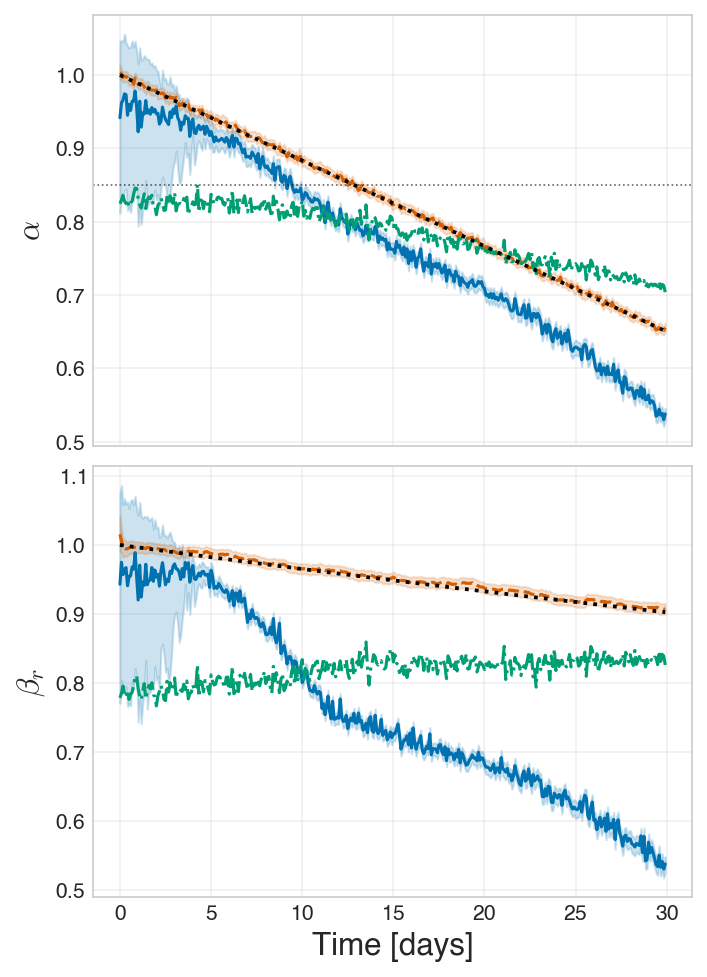

Saved nb27_sequential_tracking.png (no legend, no CNN CI)
alpha MAE:  SBI=0.0556  EKF=0.0018  CNN=0.0606
beta_r MAE: SBI=0.1917  EKF=0.0035  CNN=0.1319


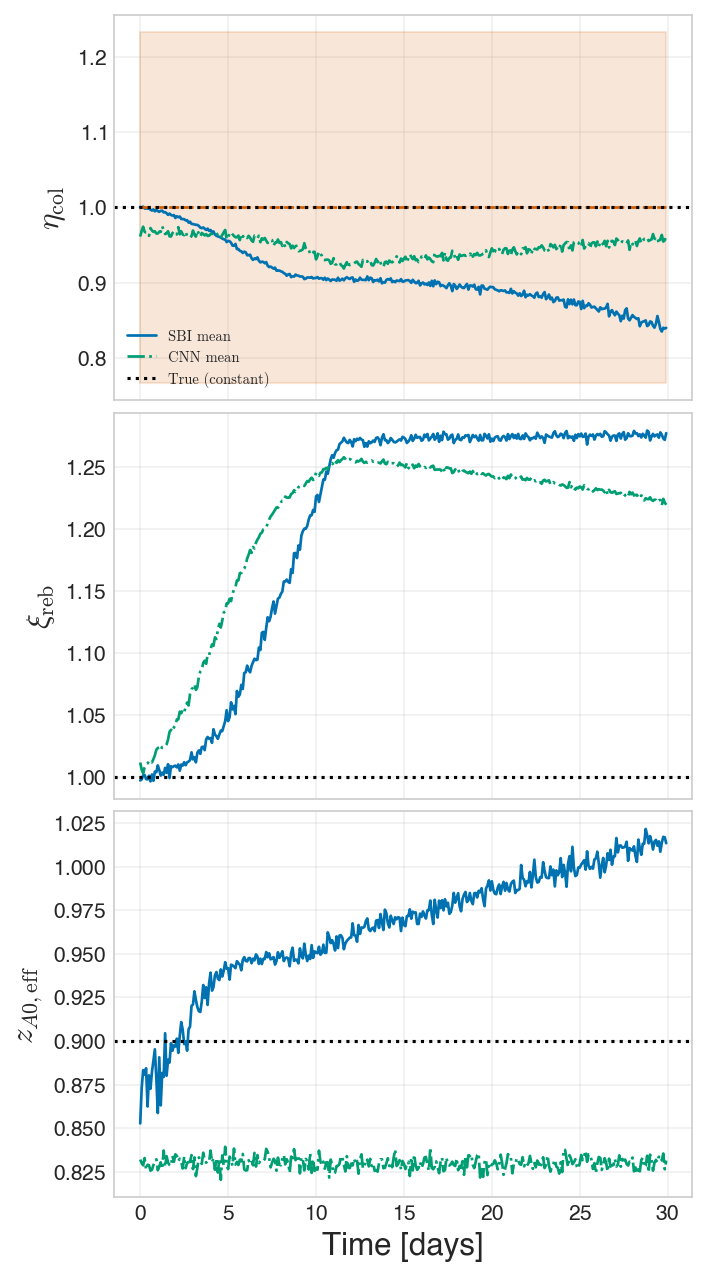

Saved nb27_sequential_tracking_other_params.png
(xi_reb, z_A0_eff have no EKF trace: not part of this EKF's augmented state.)


In [18]:
ekf_alpha_lo_seq = ekf_alpha_seq - 1.645 * ekf_alpha_std_seq
ekf_alpha_hi_seq = ekf_alpha_seq + 1.645 * ekf_alpha_std_seq
ekf_beta_lo_seq  = ekf_beta_seq  - 1.645 * ekf_beta_std_seq
ekf_beta_hi_seq  = ekf_beta_seq  + 1.645 * ekf_beta_std_seq
ekf_eta_lo_seq   = ekf_eta_seq   - 1.645 * ekf_eta_std_seq
ekf_eta_hi_seq   = ekf_eta_seq   + 1.645 * ekf_eta_std_seq

font_kwargs = {"fontname": "Helvetica"}
CNN_COLOR = OI[3]

# --- Main figure: alpha/beta_r, SBI vs EKF vs CNN vs True ---
fig, axes = plt.subplots(2, 1, figsize=(4.6, 6.4), sharex=True, constrained_layout=True)

ax = axes[0]
ax.fill_between(t_days_seq, sbi_alpha_lo_seq, sbi_alpha_hi_seq, alpha=0.20, color=SBI_COLOR)
ax.plot(t_days_seq, sbi_alpha_mean_seq, color=SBI_COLOR, lw=1.5)
ax.fill_between(t_days_seq, ekf_alpha_lo_seq, ekf_alpha_hi_seq, alpha=0.18, color=EKF_COLOR)
ax.plot(t_days_seq, ekf_alpha_seq, color=EKF_COLOR, lw=1.5, ls="--")
ax.plot(t_days_seq, cnn_alpha_mean_seq, color=CNN_COLOR, lw=1.5, ls="-.")
ax.plot(t_days_seq, alpha_true_seq, color="k", lw=1.8, ls=":", zorder=5)
ax.axhline(0.85, color=OI[0], lw=0.8, ls=":", alpha=0.6)
ax.set_ylabel(PARAM_LABELS_SYS2["alpha"], fontsize=15, **font_kwargs)
ax.grid(alpha=0.3)

ax = axes[1]
ax.fill_between(t_days_seq, sbi_beta_lo_seq, sbi_beta_hi_seq, alpha=0.20, color=SBI_COLOR)
ax.plot(t_days_seq, sbi_beta_mean_seq, color=SBI_COLOR, lw=1.5)
ax.fill_between(t_days_seq, ekf_beta_lo_seq, ekf_beta_hi_seq, alpha=0.18, color=EKF_COLOR)
ax.plot(t_days_seq, ekf_beta_seq, color=EKF_COLOR, lw=1.5, ls="--")
ax.plot(t_days_seq, cnn_beta_mean_seq, color=CNN_COLOR, lw=1.5, ls="-.")
ax.plot(t_days_seq, beta_r_true_seq, color="k", lw=1.8, ls=":", zorder=5)
ax.set_xlabel("Time [days]", fontsize=15, **font_kwargs)
ax.set_ylabel(PARAM_LABELS_SYS2["beta_r"], fontsize=15, **font_kwargs)
ax.grid(alpha=0.3)
# No fixed ylim here -- nb27 found and fixed a bug where a hardcoded range clipped most
# of the SBI beta_r divergence out of the visible plot. Autoscale instead.

for ax in axes:
    ax.tick_params(axis="both", labelsize=10)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontname("Helvetica")

save_fig(fig, FIGURES / "nb27_sequential_tracking")
plt.show()
print("Saved nb27_sequential_tracking.png (no legend, no CNN CI)")
print(f"alpha MAE:  SBI={mae_sbi_alpha_seq:.4f}  EKF={mae_ekf_alpha_seq:.4f}  CNN={mae_cnn_alpha_seq:.4f}")
print(f"beta_r MAE: SBI={mae_sbi_beta_seq:.4f}  EKF={mae_ekf_beta_seq:.4f}  CNN={mae_cnn_beta_seq:.4f}")

# --- Validity-check figure: the three parameters held constant in this scenario ---
# (eta_col, xi_reb, z_A0_eff). Not referenced by main.tex -- supports the markdown
# discussion below on whether/how these could be tracked here.
fig2, axes2 = plt.subplots(3, 1, figsize=(4.6, 8.4), sharex=True, constrained_layout=True)
other_labels_tex = [PARAM_LABELS_SYS2["eta_col"], PARAM_LABELS_SYS2["xi_reb"], PARAM_LABELS_SYS2["z_A0_eff"]]

for k, (ax, label_tex, name, true_val) in enumerate(zip(axes2, other_labels_tex, other_names_seq, other_true_seq)):
    ax.plot(t_days_seq, sbi_other_mean_seq[:, k], color=SBI_COLOR, lw=1.3,
            label="SBI mean" if k == 0 else None)
    ax.plot(t_days_seq, cnn_other_mean_seq[:, k], color=CNN_COLOR, lw=1.3, ls="-.",
            label="CNN mean" if k == 0 else None)
    if name == "eta_col":
        ax.fill_between(t_days_seq, ekf_eta_lo_seq, ekf_eta_hi_seq, alpha=0.15, color=EKF_COLOR)
        ax.plot(t_days_seq, ekf_eta_seq, color=EKF_COLOR, lw=1.3, ls="--")
    ax.axhline(true_val, color="k", lw=1.5, ls=":", label="True (constant)" if k == 0 else None)
    ax.set_ylabel(label_tex, fontsize=15, **font_kwargs)
    ax.grid(alpha=0.3)

axes2[0].legend(fontsize=7, loc="best")
axes2[-1].set_xlabel("Time [days]", fontsize=15, **font_kwargs)

for ax in axes2:
    ax.tick_params(axis="both", labelsize=10)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontname("Helvetica")

save_fig(fig2, FIGURES / "nb27_sequential_tracking_other_params")
plt.show()
print("Saved nb27_sequential_tracking_other_params.png")
print("(xi_reb, z_A0_eff have no EKF trace: not part of this EKF's augmented state.)")


### Can the other three System~II fault parameters be tracked here?

**Short answer:** for SBI (hand-crafted and CNN) — yes, trivially, and it's shown
above; for the EKF as currently built — no, and it is not a quick fix.

- **The scenario itself only varies $\alpha$ and $\beta_r$.** $\eta_\mathrm{col}$,
  $\xi_\mathrm{reb}$, and $z_{A0,\mathrm{eff}}$ are held at their healthy nominal
  values throughout by construction (matching `nb27`/`nb32`'s own scenario
  definition), so there is no changing trajectory to "track" for them here — the
  right question is whether each method's marginal for these three stays correctly
  flat at its true nominal value, or drifts spuriously because of a representation
  artifact correlated with the genuinely-degrading $\alpha$/$\beta_r$.
- **SBI and CNN already produce this for free.** Both posteriors are 5-D; the
  panel above simply plots the three dimensions this notebook had been discarding.
  The printed drift numbers quantify exactly how flat/honest each marginal is —
  compare against the representation artifacts already established elsewhere in
  the paper (the retracted $(\alpha,\eta_\mathrm{col})$ banana, Section~S9; the
  $(\alpha/\beta_r,\,z_{A0,\mathrm{eff}})$ confound, Section~S6b/Artefact~3) as the
  most likely source of any drift, rather than a genuine new finding.
- **The EKF cannot, and this is a design limit, not a missing feature.** This
  EKF observes only 3 of the S-B structure's 9 measured channels
  ($T_r$, $T_j$, $F_{R,\mathrm{norm}}$) and augments only 3 of the 5 parameters
  ($\alpha$, $\beta_r$, $\eta_\mathrm{col}$) onto the plant state. $\eta_\mathrm{col}$
  is included only because it is needed to predict the observed $F_{R,\mathrm{norm}}$
  channel (via `column_qss`) — it is a nuisance parameter for the observation model,
  not evidence the EKF can track a genuinely time-varying $\eta_\mathrm{col}$.
  $\xi_\mathrm{reb}$ and $z_{A0,\mathrm{eff}}$ are hardcoded constants in
  `rhs_fn_seq`/`obs_fn_seq` — they are never estimated, because neither one enters
  any of the 3 observed channels: $\xi_\mathrm{reb}$ (reboiler fouling) only affects
  reboiler-side channels ($T_\mathrm{reb}$, $Q_\mathrm{reb}$, $V_\mathrm{norm}$,
  $F_{B,\mathrm{norm}}$), none of which this EKF observes.
- **Does extending it make sense?** In principle yes: S-B measures all of
  $T_\mathrm{reb}$, $Q_\mathrm{reb}$, $F_{B,\mathrm{norm}}$, $V_\mathrm{norm}$
  already (`compute_summaries`/the CNN both see them), and the nominal-point FIM
  above (Section~6) shows positive diagonal information for every one of the 5
  parameters under the full 9-channel S-B measurement — so $\xi_\mathrm{reb}$ and
  $z_{A0,\mathrm{eff}}$ are not fundamentally unobservable in this plant. Doing it
  properly would mean growing the EKF from a 9-state/3-observation model to an
  11-state/9-observation model: re-deriving `obs_fn_seq` for the reboiler-side
  channels (a second `column_qss`-style QSS relation, not just adding rows) and
  re-tuning $Q$/$R$ for the enlarged state — a real EKF-design task, not a
  one-line change, and out of scope for a publication-figures notebook. Flagging
  it here rather than silently only tracking 2 of 5 parameters.
